# Analyse exploratoire des performances étudiantes

## Contexte du projet

Dans un environnement éducatif de plus en plus axé sur les données, il est essentiel pour les établissements scolaires de comprendre les facteurs qui influencent la performance académique des étudiants.  
Les résultats peuvent être liés à des aspects socio-économiques, à l'engagement personnel, à l'accès aux ressources ou encore à la qualité de l'enseignement.

L'objectif de ce projet est de **prédire le score d'examen** des étudiants à partir de leurs caractéristiques, afin d'identifier les étudiants à risque et d'aider les éducateurs à intervenir de manière proactive.

Pour cela, un jeu de données de 6607 étudiants a été constitué. Il comprend des informations personnelles, familiales et scolaires, ainsi que le score obtenu à l'examen.  
La démarche va suivre les étapes classiques d'un projet de machine learning supervisé : exploration, prétraitement, modélisation, évaluation et déploiement d'une API de prédiction.

Ce notebook constitue la première phase : l'analyse exploratoire des données.

## 1. Objectif de l'analyse exploratoire

Maintenant que le cadre du projet est posé, ce notebook se concentre sur la première phase : 
l'exploration des données. Avant de construire un modèle prédictif, il est indispensable de 
comprendre la structure du jeu de données, d'identifier les éventuelles valeurs manquantes, 
de visualiser les distributions et de repérer les variables les plus liées au score d'examen.

Pour rappel, le jeu de données contient 6607 étudiants décrits par 20 variables, dont la cible 
Exam_Score. Ces variables couvrent :

- Le profil personnel de l'étudiant : genre, activité physique, heures de sommeil, etc.
- L'environnement familial : implication parentale, revenus, niveau d'éducation des parents, etc.
- Le contexte scolaire : heures d'étude, assiduité, scores antérieurs, type d'école, etc.

L'analyse va suivre plusieurs étapes :

1. Chargement et première inspection des données
2. Traitement des valeurs manquantes
3. Analyse univariée de la variable cible
4. Analyse univariée des variables explicatives numériques puis catégorielles
5. Analyse bivariée : relations entre chaque variable et le score
6. Analyse des corrélations et des interactions
7. Synthèse et premières décisions pour la modélisation

Chaque résultat visuel sera accompagné d'un tableau de valeurs et d'un commentaire afin de 
garder une trace écrite des observations et des choix effectués.

## 2. Importation des librairies et configuration

Cette section charge l'ensemble des bibliothèques nécessaires à l'analyse exploratoire.  
La graine aléatoire est fixée pour garantir la reproductibilité des résultats.

In [24]:
# Ignorer tous les avertissements – doit être exécuté avant tout import
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno

# Profilage automatique
from ydata_profiling import ProfileReport

# Outils système
from pathlib import Path
import shutil
import kagglehub

# Configuration reproductible
SEED = 42
np.random.seed(SEED)

# Affichage pandas : toutes les colonnes, 2 décimales
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

# Style des graphiques seaborn
sns.set_theme(style='whitegrid', palette='muted', context='notebook')

print("Librairies importées et configurées.")

Librairies importées et configurées.


## 3. Récupération et chargement des données

Le dataset est hébergé sur Kaggle. Pour garantir la reproductibilité et éviter les téléchargements manuels, la librairie **kagglehub** est utilisée. Une fois téléchargé, le fichier est copié dans le dossier **data/raw** du projet.

In [2]:
# Téléchargement du dataset depuis Kaggle
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")
print("Chemin d'accès aux fichiers :", path)

# Copie du fichier CSV dans data/raw
RAW_DIR = Path("../data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)
source_file = Path(path) / "StudentPerformanceFactors.csv"
shutil.copy(source_file, RAW_DIR / "StudentPerformanceFactors.csv")
print("Fichier copié dans :", RAW_DIR)

Chemin d'accès aux fichiers : C:\Users\mourt\.cache\kagglehub\datasets\lainguyn123\student-performance-factors\versions\9
Fichier copié dans : ..\data\raw


Le fichier est maintenant chargé dans un DataFrame pandas.

In [3]:
# Chargement des données
data = pd.read_csv(RAW_DIR / "StudentPerformanceFactors.csv")

### Premières vérifications

Dimensions du dataset, aperçu des premières et dernières lignes.

In [4]:
# Dimensions
print("Dimensions (lignes, colonnes) :", data.shape)

# Premières lignes
display(data.head(10))

# Dernières lignes
display(data.tail(10))

Dimensions (lignes, colonnes) : (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6597,16,91,High,Medium,Yes,6,72,High,Yes,0,High,High,Public,Negative,2,No,Postgraduate,Near,Female,70
6598,9,87,Low,Medium,Yes,6,64,Medium,Yes,1,High,Medium,Public,Neutral,2,No,High School,Near,Female,64
6599,30,94,Medium,Low,No,5,52,Low,No,3,High,Medium,Private,Neutral,2,No,Postgraduate,Moderate,Female,70
6600,12,98,Medium,Low,Yes,4,54,Medium,Yes,2,Medium,High,Private,Neutral,3,No,High School,Near,Female,67
6601,20,83,Medium,Low,No,6,51,Low,Yes,2,Medium,Medium,Public,Neutral,4,No,High School,Moderate,Female,65
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


Un tableau récapitulatif des colonnes avec leur type et leur signification est construit pour servir de référence tout au long de l'analyse.

In [5]:
# Création d'un DataFrame descriptif des colonnes
col_info = pd.DataFrame({
    'Colonne': data.columns,
    'Type': data.dtypes.values,
    'Description': [
        'Heures d\'étude par semaine',
        'Taux d\'assiduité (en %)',
        'Implication des parents',
        'Accès aux ressources éducatives',
        'Participation à des activités extrascolaires',
        'Heures de sommeil par nuit',
        'Scores antérieurs',
        'Niveau de motivation',
        'Accès à Internet',
        'Nombre de séances de tutorat',
        'Revenu familial',
        'Qualité perçue de l\'enseignant',
        'Type d\'école',
        'Influence des pairs',
        'Heures d\'activité physique par semaine',
        'Troubles de l\'apprentissage',
        'Niveau d\'éducation des parents',
        'Distance au domicile',
        'Genre',
        'Score à l\'examen (cible)'
    ]
})
display(col_info)

,Colonne,Type,Description
0,Hours_Studied,int64,Heures d'étude par semaine
1,Attendance,int64,Taux d'assiduité (en %)
2,Parental_Involvement,object,Implication des parents
3,Access_to_Resources,object,Accès aux ressources éducatives
4,Extracurricular_Activities,object,Participation à des activités extrascolaires
5,Sleep_Hours,int64,Heures de sommeil par nuit
6,Previous_Scores,int64,Scores antérieurs
7,Motivation_Level,object,Niveau de motivation
8,Internet_Access,object,Accès à Internet
9,Tutoring_Sessions,int64,Nombre de séances de tutorat


## 4. Première vue d’ensemble

Avant toute visualisation détaillée, un rapide examen des types de données, du nombre de valeurs non nulles et des statistiques descriptives permet de confirmer les informations du cahier des charges et de repérer d’éventuelles anomalies.

In [6]:
# Résumé technique : types, nombre de non-null, mémoire utilisée
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Le tableau ci-dessous regroupe les types et le nombre de valeurs manquantes par colonne.  
Les trois colonnes déjà identifiées (Teacher_Quality, Parental_Education_Level, Distance_from_Home) sont les seules à présenter des valeurs absentes.

In [7]:
# Construction d'un DataFrame récapitulatif
summary_df = pd.DataFrame({
    'Colonne': data.columns,
    'Type': data.dtypes.values,
    'Non_Null': data.notnull().sum().values,
    'Valeurs_Manquantes': data.isnull().sum().values
})
summary_df['Pourcentage_NA'] = (100 * summary_df['Valeurs_Manquantes'] / len(data)).round(2)
display(summary_df)

,Colonne,Type,Non_Null,Valeurs_Manquantes,Pourcentage_NA
0,Hours_Studied,int64,6607,0,0.00
1,Attendance,int64,6607,0,0.00
2,Parental_Involvement,object,6607,0,0.00
3,Access_to_Resources,object,6607,0,0.00
4,Extracurricular_Activities,object,6607,0,0.00
5,Sleep_Hours,int64,6607,0,0.00
6,Previous_Scores,int64,6607,0,0.00
7,Motivation_Level,object,6607,0,0.00
8,Internet_Access,object,6607,0,0.00
9,Tutoring_Sessions,int64,6607,0,0.00


Les statistiques descriptives (effectifs, moyenne, quartiles, etc.) sont affichées pour toutes les variables, numériques et catégorielles.

In [8]:
# Statistiques descriptives pour toutes les colonnes
data.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.00,6607.00,6607,6607,6607,6607.00,6607.00,6607,6607,6607.00,6607,6529,6607,6607,6607.00,6607,6517,6540,6607,6607.00
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.98,79.98,NaN,NaN,NaN,7.03,75.07,NaN,NaN,1.49,NaN,NaN,NaN,NaN,2.97,NaN,NaN,NaN,NaN,67.24
std,5.99,11.55,NaN,NaN,NaN,1.47,14.40,NaN,NaN,1.23,NaN,NaN,NaN,NaN,1.03,NaN,NaN,NaN,NaN,3.89
min,1.00,60.00,NaN,NaN,NaN,4.00,50.00,NaN,NaN,0.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,55.00
25%,16.00,70.00,NaN,NaN,NaN,6.00,63.00,NaN,NaN,1.00,NaN,NaN,NaN,NaN,2.00,NaN,NaN,NaN,NaN,65.00
50%,20.00,80.00,NaN,NaN,NaN,7.00,75.00,NaN,NaN,1.00,NaN,NaN,NaN,NaN,3.00,NaN,NaN,NaN,NaN,67.00
75%,24.00,90.00,NaN,NaN,NaN,8.00,88.00,NaN,NaN,2.00,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,NaN,69.00


### Analyse des premières informations

Le jeu de données contient bien 6607 lignes et 20 colonnes, comme annoncé.  
La cible **Exam_Score** est complète (aucune valeur manquante), ce qui simplifie la phase d’entraînement : aucune ligne n’aura besoin d’être supprimée pour absence de valeur cible.

Les types de données sont cohérents : les variables numériques sont bien de type int64, les catégorielles de type object.  
Aucune anomalie immédiate n’est détectée.

### Valeurs manquantes

Trois colonnes présentent des valeurs absentes, avec des taux très faibles :

- **Teacher_Quality** : 78 valeurs manquantes (1,18 %)
- **Parental_Education_Level** : 90 valeurs manquantes (1,36 %)
- **Distance_from_Home** : 67 valeurs manquantes (1,01 %)

Ces proportions restant inférieures à 2 %, une imputation simple (mode pour les variables catégorielles) sera envisagée lors du prétraitement. Pour l’exploration, les valeurs manquantes seront temporairement remplacées par la mention “Missing” lorsque cela est nécessaire.

### Statistiques descriptives : variables numériques

Le tableau ci-dessous synthétise les indicateurs clés pour les variables numériques.

In [9]:
# Construction d'un tableau synthétique des variables numériques
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
            'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
num_summary = data[num_cols].describe().T
num_summary = num_summary.round(2)
num_summary['étendue'] = num_summary['max'] - num_summary['min']
display(num_summary[['min', 'max', 'mean', 'std', 'étendue']])

,min,max,mean,std,étendue
Hours_Studied,1.00,44.00,19.98,5.99,43.00
Attendance,60.00,100.00,79.98,11.55,40.00
Sleep_Hours,4.00,10.00,7.03,1.47,6.00
Previous_Scores,50.00,100.00,75.07,14.40,50.00
Tutoring_Sessions,0.00,8.00,1.49,1.23,8.00
Physical_Activity,0.00,6.00,2.97,1.03,6.00
Exam_Score,55.00,101.00,67.24,3.89,46.00


Quelques observations à retenir :

- **Exam_Score** s’étend de 55 à 101, avec une moyenne de 67,24 et un écart-type de 3,89.  
  La dispersion est modérée, les scores restent relativement groupés autour de la moyenne.
- **Hours_Studied** varie de 1 à 44 heures par semaine (moyenne 20h). L’étendue est large mais plausible.
- **Attendance** est globalement élevé (minimum 60 %, moyenne 80 %).  
- **Sleep_Hours** s’étend de 4 à 10 heures, avec une moyenne de 7 heures, ce qui correspond à une population adolescente/jeune adulte.
- **Previous_Scores** a une distribution comparable à celle de la cible (min 50, max 100, moyenne 75), ce qui suggère une forte corrélation.
- **Tutoring_Sessions** est limité à 8 séances maximum, avec une moyenne de 1,49. La plupart des étudiants ont peu de tutorat.
- **Physical_Activity** va de 0 à 6 heures, avec une moyenne de 2,97 heures.

### Variables catégorielles

Les fréquences des modalités ont été examinées brièvement dans le **describe**. On note que :

- **Internet_Access** est très déséquilibré (92,4 % de “Yes”), ce qui peut réduire son pouvoir discriminant.
- **Learning_Disabilities** est également déséquilibré (89,5 % de “No”), les étudiants avec des troubles de l’apprentissage étant minoritaires.
- Les autres variables ont des répartitions plutôt équilibrées ou avec une modalité légèrement majoritaire.
- Les trois variables avec des valeurs manquantes ont aussi des modalités variées, l’imputation par le mode semble adaptée.


## 5. Visualisation des valeurs manquantes

Avant d’aborder les distributions, un examen visuel des absences de données permet de confirmer leur localisation et de vérifier si elles semblent apparaître de manière aléatoire.

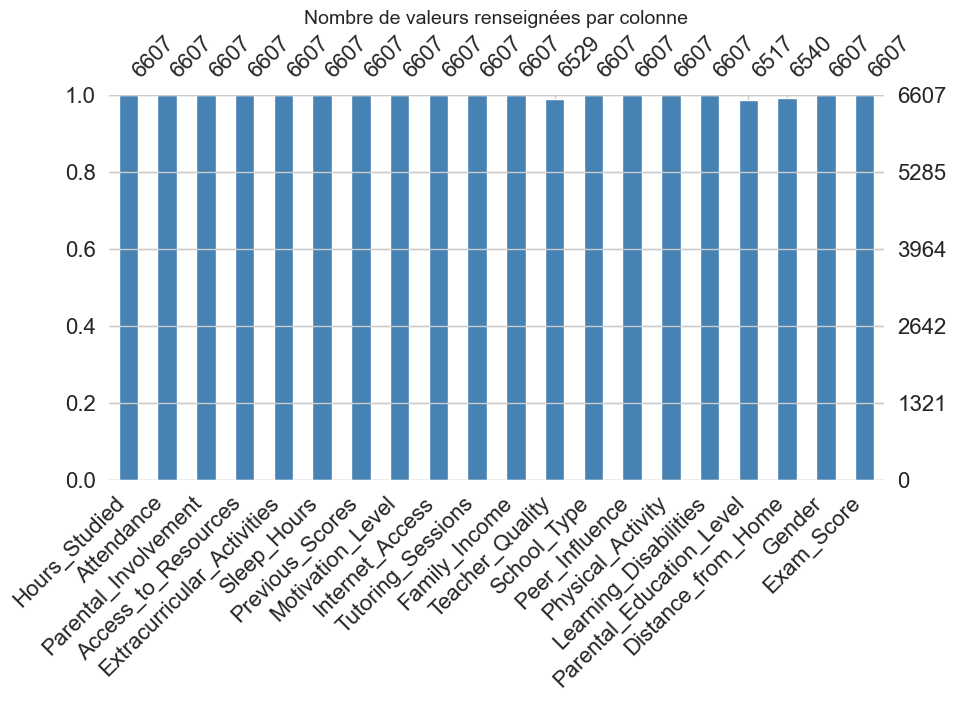

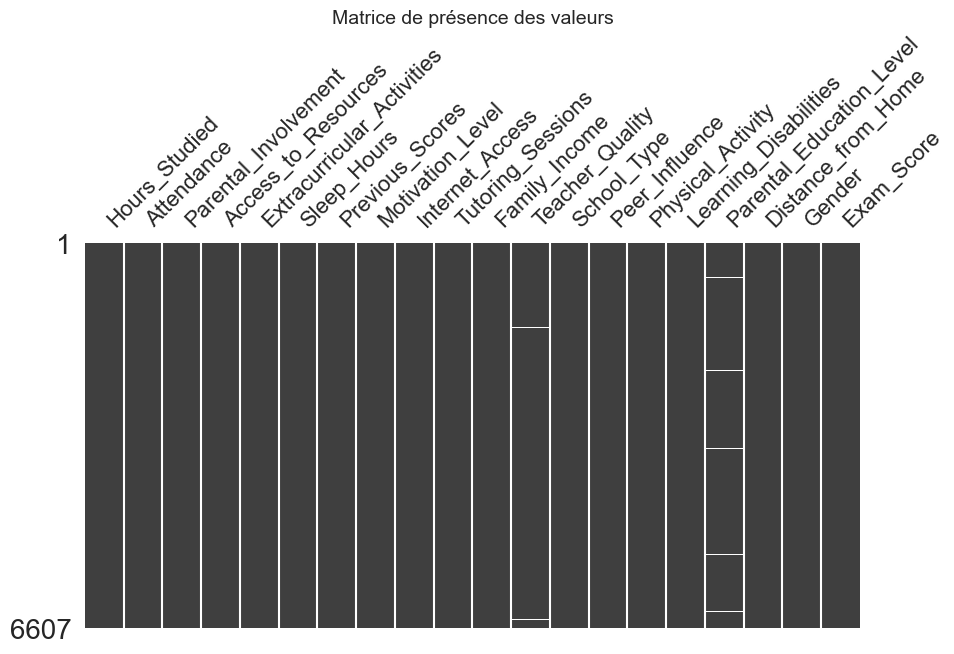

In [10]:
# Bar chart : nombre de valeurs présentes par colonne
msno.bar(data, figsize=(10, 5), color='steelblue')
plt.title("Nombre de valeurs renseignées par colonne", fontsize=14)
plt.show()

# Matrix : répartition des valeurs manquantes ligne par ligne
msno.matrix(data, figsize=(10, 5), sparkline=False)
plt.title("Matrice de présence des valeurs", fontsize=14)
plt.show()

### Observations

Le diagramme en barres confirme que seules trois colonnes sont concernées par des valeurs manquantes :

- **Teacher_Quality**
- **Parental_Education_Level**
- **Distance_from_Home**

La matrice de présence montre que les absences sont dispersées sur l’ensemble des lignes, sans motif particulier.  
Aucune concentration anormale n’apparaît, ce qui suggère que les données manquantes sont réparties de façon aléatoire.  
Cette répartition justifiera une imputation simple lors du prétraitement, sans risque de biaiser fortement l’analyse.

Un tableau synthétique reprend les comptages déjà établis.

In [11]:
# Rappel des colonnes avec NA
na_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
na_summary = pd.DataFrame({
    'Colonne': na_cols,
    'Valeurs manquantes': [data[col].isnull().sum() for col in na_cols],
    'Pourcentage': [round(100 * data[col].isnull().sum() / len(data), 2) for col in na_cols]
})
display(na_summary)

,Colonne,Valeurs manquantes,Pourcentage
0,Teacher_Quality,78,1.18
1,Parental_Education_Level,90,1.36
2,Distance_from_Home,67,1.01


## 6. Analyse univariée de la variable cible

L’objectif est d’examiner la distribution du score d’examen, de repérer d’éventuelles valeurs extrêmes et d’évaluer si une transformation sera nécessaire pour la modélisation.

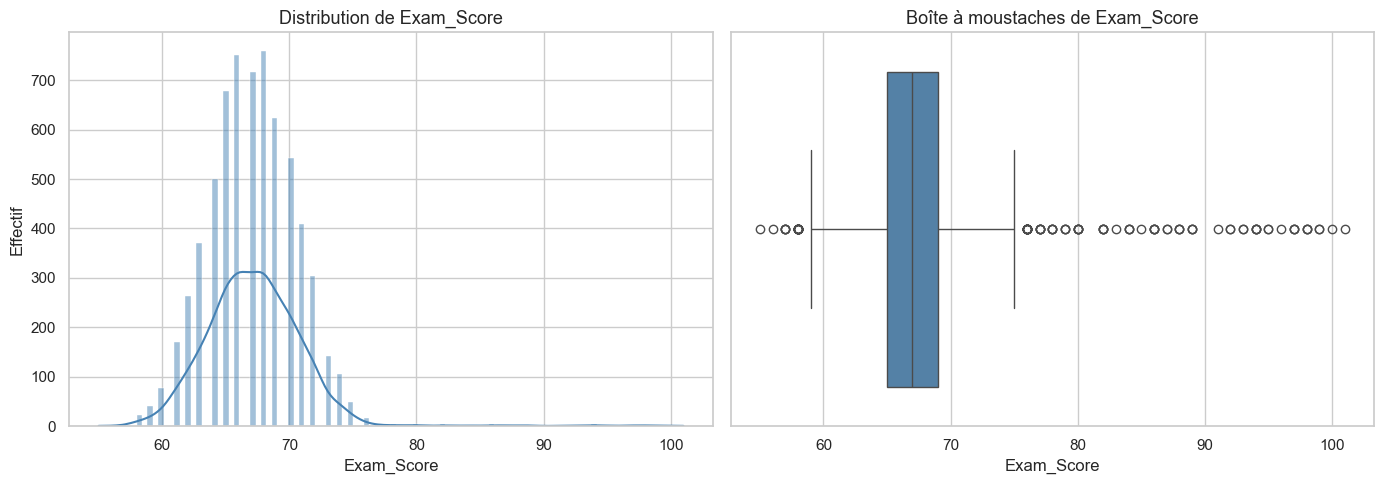

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme avec KDE
sns.histplot(data['Exam_Score'], kde=True, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution de Exam_Score', fontsize=13)
axes[0].set_xlabel('Exam_Score')
axes[0].set_ylabel('Effectif')

# Boxplot
sns.boxplot(x=data['Exam_Score'], color='steelblue', ax=axes[1])
axes[1].set_title('Boîte à moustaches de Exam_Score', fontsize=13)
axes[1].set_xlabel('Exam_Score')

plt.tight_layout()
plt.show()

In [13]:
# Calcul des statistiques
exam_stats = {
    'Minimum': data['Exam_Score'].min(),
    'Maximum': data['Exam_Score'].max(),
    'Moyenne': data['Exam_Score'].mean(),
    'Médiane': data['Exam_Score'].median(),
    'Écart-type': data['Exam_Score'].std(),
    'Asymétrie (skewness)': data['Exam_Score'].skew(),
    'Aplatissement (kurtosis)': data['Exam_Score'].kurtosis()
}

# Affichage sous forme de tableau
exam_stats_df = pd.DataFrame(list(exam_stats.items()), columns=['Statistique', 'Valeur'])
exam_stats_df['Valeur'] = exam_stats_df['Valeur'].round(2)
display(exam_stats_df)

,Statistique,Valeur
0,Minimum,55.00
1,Maximum,101.00
2,Moyenne,67.24
3,Médiane,67.00
4,Écart-type,3.89
5,Asymétrie (skewness),1.64
6,Aplatissement (kurtosis),10.58


### Analyse de la distribution

Le score d'examen s'étend de 55 à 101, avec une moyenne de 67,24 et une médiane de 67,00.  
La proximité entre la moyenne et la médiane pourrait laisser penser à une distribution symétrique, mais les coefficients d'asymétrie et d'aplatissement racontent une autre histoire.

L'asymétrie (skewness) est de **1,64**, ce qui indique une queue étalée vers la droite. Concrètement, la majorité des étudiants ont des scores regroupés entre 63 et 71, mais quelques étudiants obtiennent des résultats nettement plus élevés, tirant la distribution vers la droite.

L'aplatissement (kurtosis) est de **10,58**, bien supérieur à 3 (valeur de référence d'une loi normale). Cela signifie que la distribution est très concentrée autour de la moyenne, avec des queues plus épaisses qu'une loi normale. Autrement dit, les valeurs extrêmes (très basses ou très élevées) sont plus fréquentes que ce que l'on attendrait d'une distribution gaussienne.

L'écart-type de 3,89 confirme une dispersion modérée : environ 68 % des scores se situent entre 63,35 et 71,13 (moyenne ± un écart-type).

Le maximum relevé est de 101, ce qui dépasse la valeur théorique de 100 généralement attendue pour un examen. Une seule observation est concernée. Il conviendra de vérifier cette ligne lors du nettoyage : s'agit-il d'une erreur de saisie ou d'un bonus exceptionnel ? Dans le doute, cette valeur pourra être conservée pour l'exploration, mais ramenée à 100 lors du prétraitement si nécessaire.

Pour la modélisation, cette asymétrie et cet aplatissement ne remettent pas en cause l'utilisation de modèles linéaires, mais ils justifient de tester également des modèles plus robustes aux valeurs extrêmes (arbres de décision, forêts aléatoires, gradient boosting) et de surveiller les résidus lors de l'évaluation.

## 7. Analyse univariée des variables explicatives numériques

Six variables numériques décrivent les étudiants. Avant d’étudier leurs liens avec le score d’examen, il est utile d’examiner leur distribution, leur étendue et la présence éventuelle de valeurs atypiques.

Pour chaque variable, un histogramme avec courbe de densité et un boxplot sont affichés.  
Un tableau synthétique rassemblera ensuite les principales statistiques.

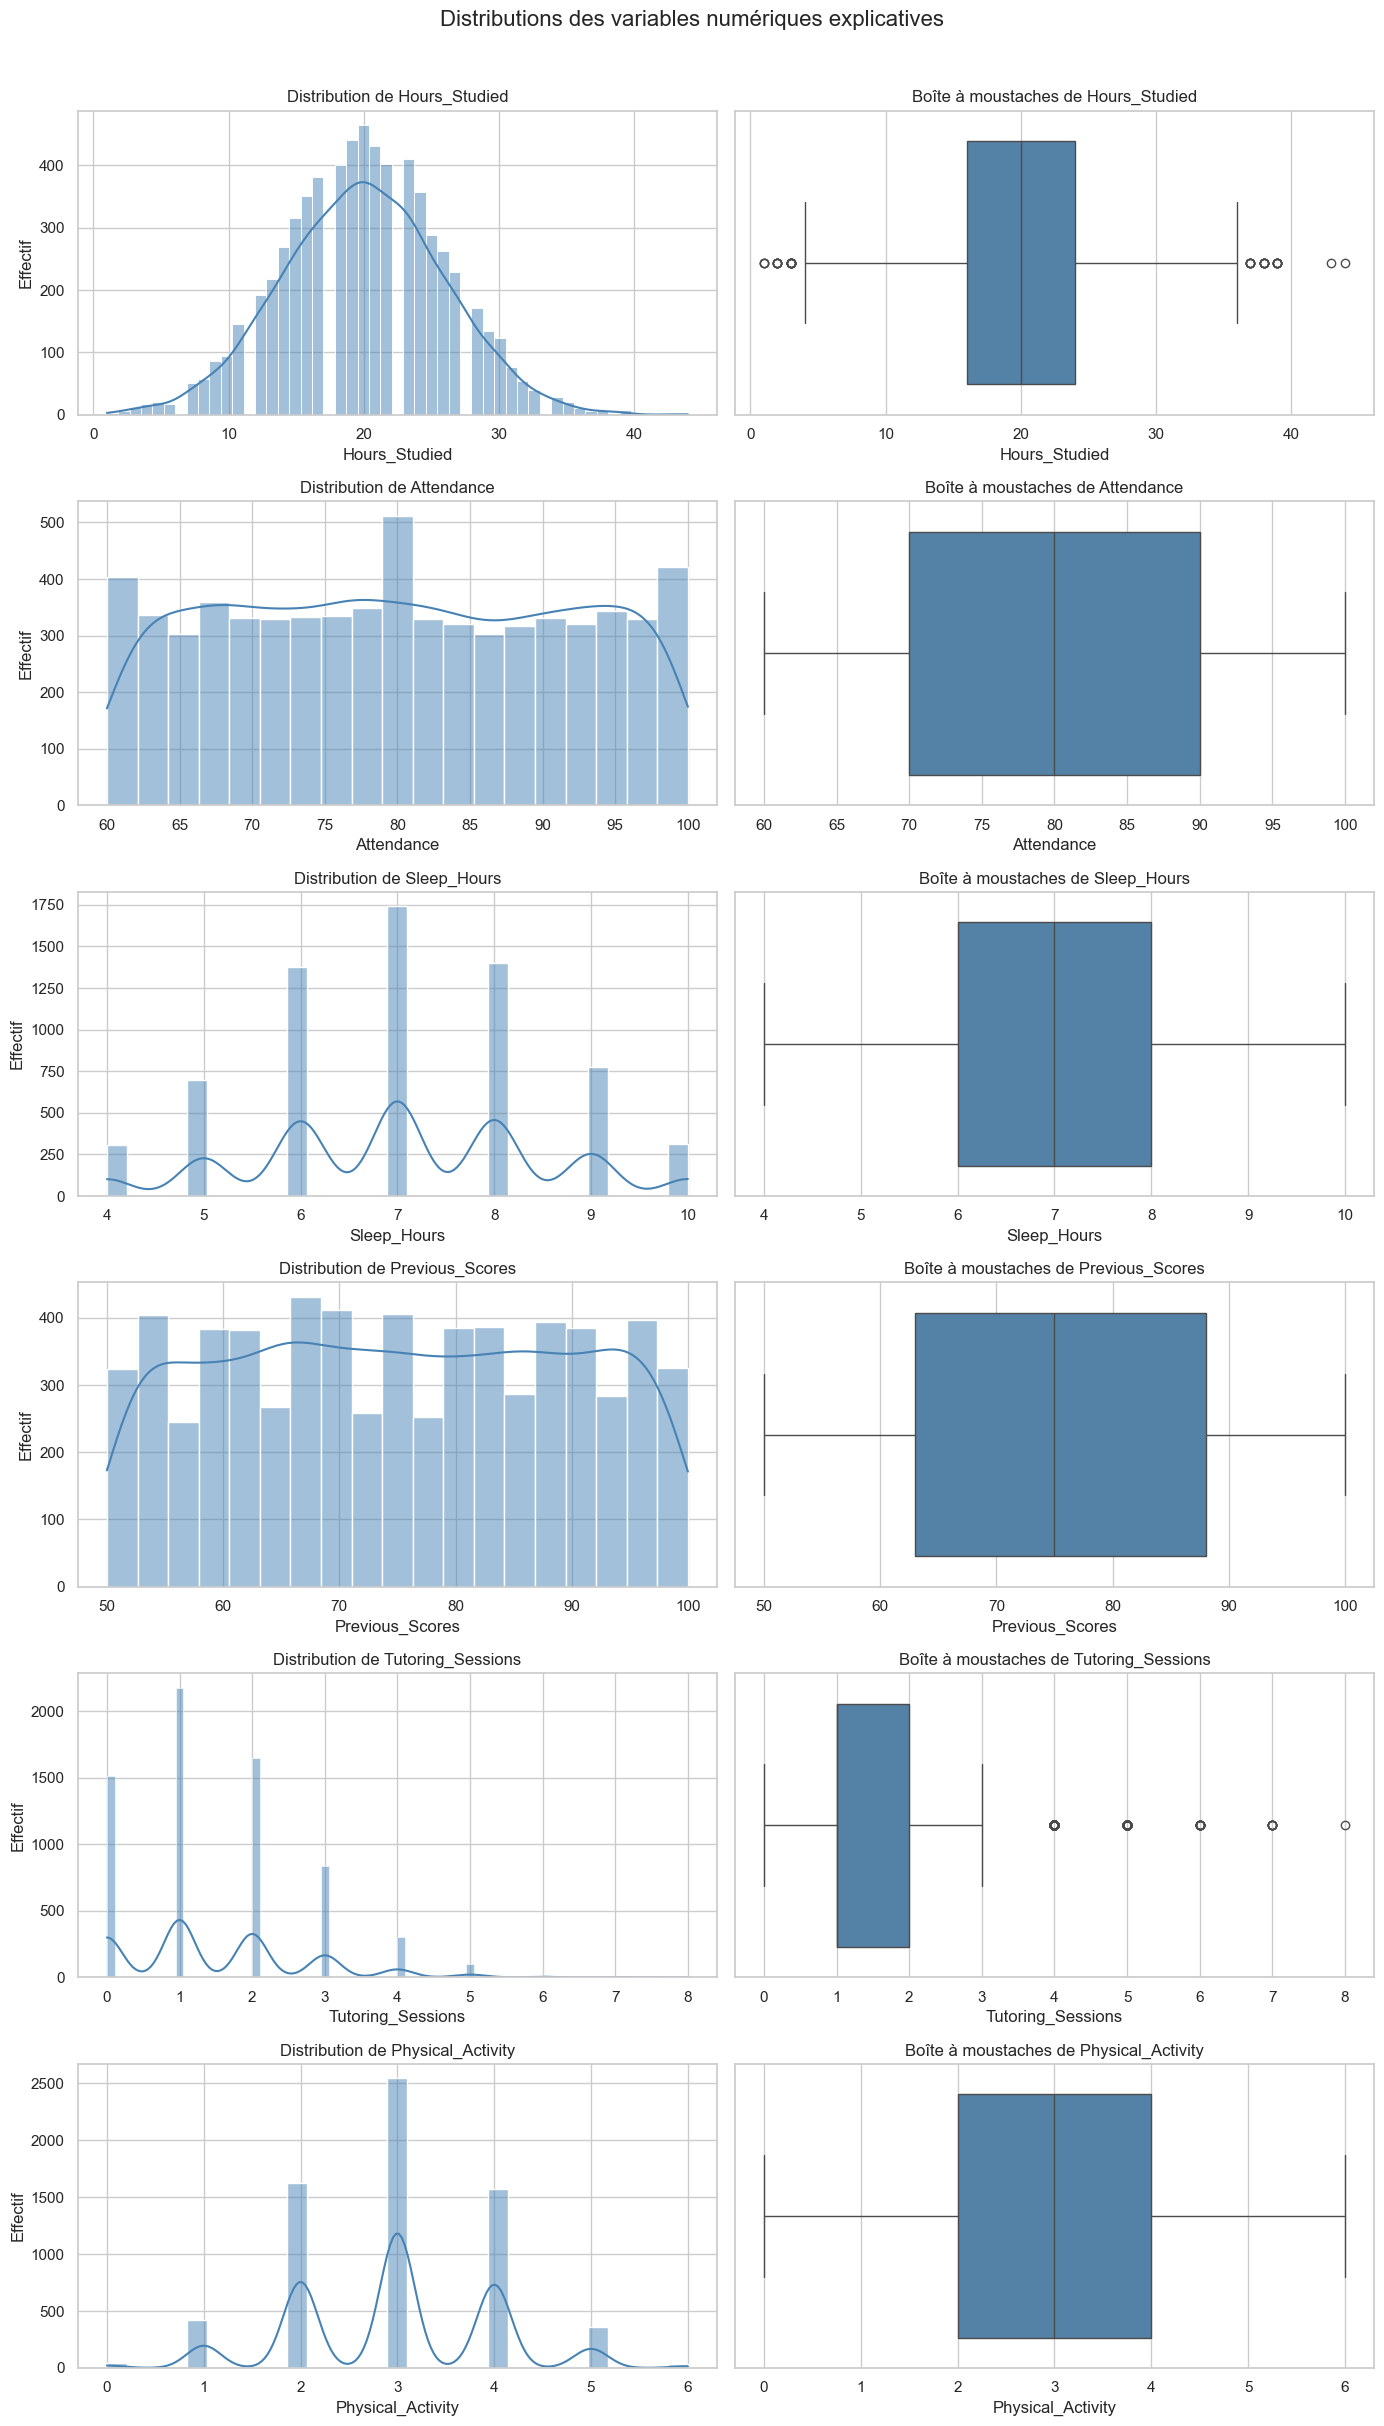

In [14]:
# Liste des variables numériques explicatives
num_vars = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
            'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

# Création de la grille de sous-graphiques (6 lignes, 2 colonnes)
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(14, 24))
fig.suptitle('Distributions des variables numériques explicatives', fontsize=16, y=1.01)

for i, var in enumerate(num_vars):
    # Histogramme + KDE
    sns.histplot(data[var], kde=True, color='steelblue', edgecolor='white', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution de {var}', fontsize=12)
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Effectif')
    
    # Boxplot
    sns.boxplot(x=data[var], color='steelblue', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boîte à moustaches de {var}', fontsize=12)
    axes[i, 1].set_xlabel(var)

plt.tight_layout()
plt.show()

In [15]:
# Statistiques descriptives des variables numériques explicatives
num_stats = data[num_vars].describe().T
num_stats['skewness'] = data[num_vars].skew().round(2)
num_stats['kurtosis'] = data[num_vars].kurtosis().round(2)
num_stats = num_stats[['min', 'max', 'mean', 'std', 'skewness', 'kurtosis']]
num_stats = num_stats.round(2)
display(num_stats)

,min,max,mean,std,skewness,kurtosis
Hours_Studied,1.00,44.00,19.98,5.99,0.01,0.02
Attendance,60.00,100.00,79.98,11.55,0.01,-1.19
Sleep_Hours,4.00,10.00,7.03,1.47,-0.02,-0.50
Previous_Scores,50.00,100.00,75.07,14.40,-0.00,-1.19
Tutoring_Sessions,0.00,8.00,1.49,1.23,0.82,0.64
Physical_Activity,0.00,6.00,2.97,1.03,-0.03,-0.06


### Analyse des distributions

Le tableau des statistiques et les graphiques permettent de dresser le portrait des six variables numériques explicatives.

- **Hours_Studied** (heures d’étude par semaine) : la variable s’étend de 1 à 44 heures, avec une moyenne de 20 heures.  
  La distribution est quasiment symétrique (skewness 0,01) et très légèrement aplatie (kurtosis 0,02).  
  Aucune valeur aberrante n’est visible sur le boxplot. Quelques étudiants dépassent 35 heures, ce qui reste plausible.

- **Attendance** (taux d’assiduité en %) : le minimum est de 60 % et le maximum de 100 %, avec une moyenne de 80 %.  
  La distribution est symétrique (skewness 0,01) mais présente un kurtosis négatif (-1,19), ce qui indique une forme plus aplatie qu’une loi normale.  
  Les absences longues sont rares, la majorité des étudiants se situant entre 70 et 90 %.

- **Sleep_Hours** (heures de sommeil par nuit) : la plage va de 4 à 10 heures, avec une moyenne de 7 heures.  
  La distribution est légèrement asymétrique à gauche (skewness -0,02) et un peu aplatie (kurtosis -0,50).  
  Le boxplot ne révèle pas d’outlier.

- **Previous_Scores** (scores antérieurs) : cette variable varie de 50 à 100, avec une moyenne de 75.  
  La distribution est symétrique (skewness proche de zéro) et aplatie (kurtosis -1,19), tout comme Attendance.  
  Les valeurs sont uniformément réparties sur l’intervalle, sans pic marqué.

- **Tutoring_Sessions** (nombre de séances de tutorat) : l’étendue est de 0 à 8 séances, pour une moyenne de 1,49.  
  La distribution est asymétrique à droite (skewness 0,82) : la grande majorité des étudiants ont très peu de séances (0 ou 1), tandis qu’une minorité en accumule jusqu’à 8.  
  Le kurtosis (0,64) indique une concentration un peu plus forte autour de la moyenne qu’une loi normale.

- **Physical_Activity** (heures d’activité physique par semaine) : la variable va de 0 à 6 heures, avec une moyenne de 3 heures.  
  La distribution est quasi symétrique (skewness -0,03) et légèrement aplatie (kurtosis -0,06).  
  Aucune valeur extrême n’est observée.

En résumé, toutes ces variables sont dépourvues d’outliers manifestes. Leurs échelles sont très différentes (heures, pourcentages, scores, comptages), ce qui justifiera une standardisation avant d’utiliser des modèles sensibles à l’échelle comme la régression ridge ou le KNN.  
La variable Tutoring_Sessions, avec sa forte asymétrie, pourrait bénéficier d’une transformation (par exemple une discrétisation ou une racine carrée) si les modèles linéaires peinent à la prendre en compte.  
Enfin, Previous_Scores est la variable qui ressemble le plus à la cible en termes de plage et de distribution, ce qui laisse présager une forte corrélation, à vérifier lors de l’analyse bivariée.

## 8. Analyse univariée des variables explicatives catégorielles

Le jeu de données comporte 13 variables catégorielles. Cette section examine la répartition des modalités de chacune, afin de repérer les éventuels déséquilibres ou les catégories très rares qui pourraient être regroupées lors du prétraitement.

Pour chaque variable, un diagramme en barres est affiché, accompagné d’un tableau des effectifs et des fréquences.

In [16]:
# Liste des variables catégorielles
cat_vars = ['Parental_Involvement', 'Access_to_Resources', 
            'Extracurricular_Activities', 'Motivation_Level', 
            'Internet_Access', 'Family_Income', 'Teacher_Quality', 
            'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
            'Parental_Education_Level', 'Distance_from_Home', 'Gender']

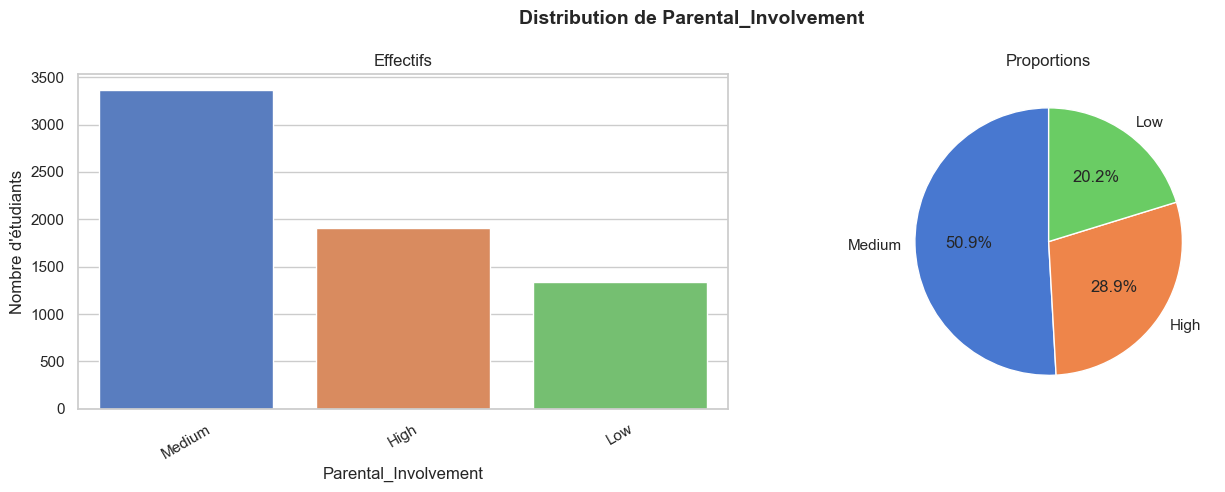

,Modalité,Effectif,Pourcentage
0,Medium,3362,50.89
1,High,1908,28.88
2,Low,1337,20.24



------------------------------------------------------------



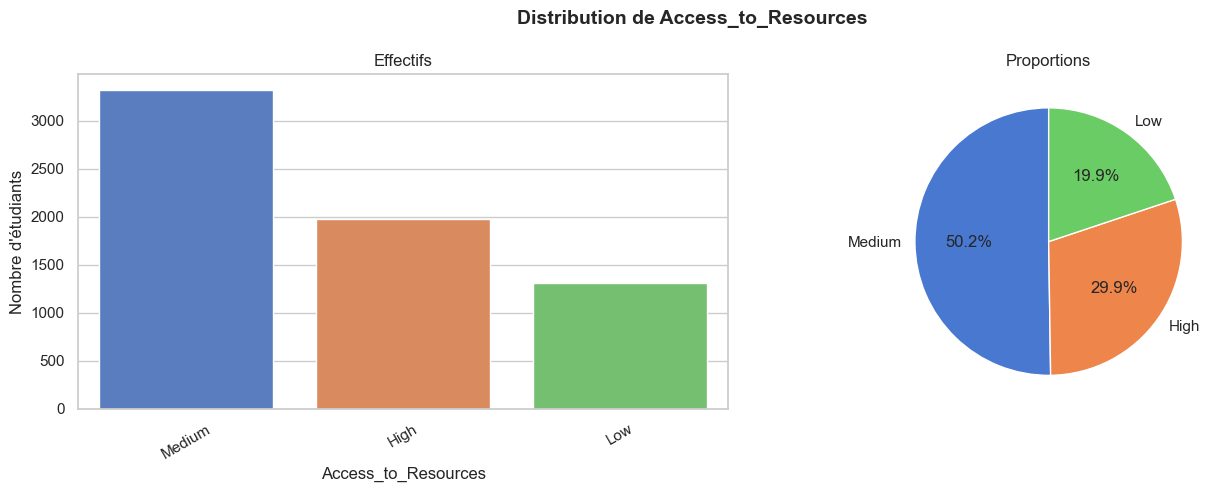

,Modalité,Effectif,Pourcentage
0,Medium,3319,50.23
1,High,1975,29.89
2,Low,1313,19.87



------------------------------------------------------------



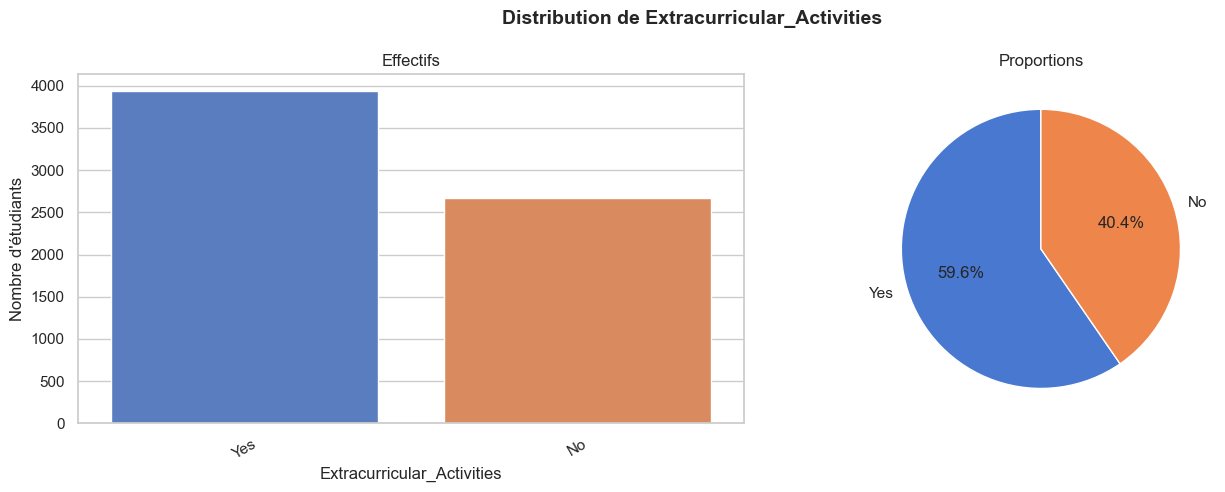

,Modalité,Effectif,Pourcentage
0,Yes,3938,59.60
1,No,2669,40.40



------------------------------------------------------------



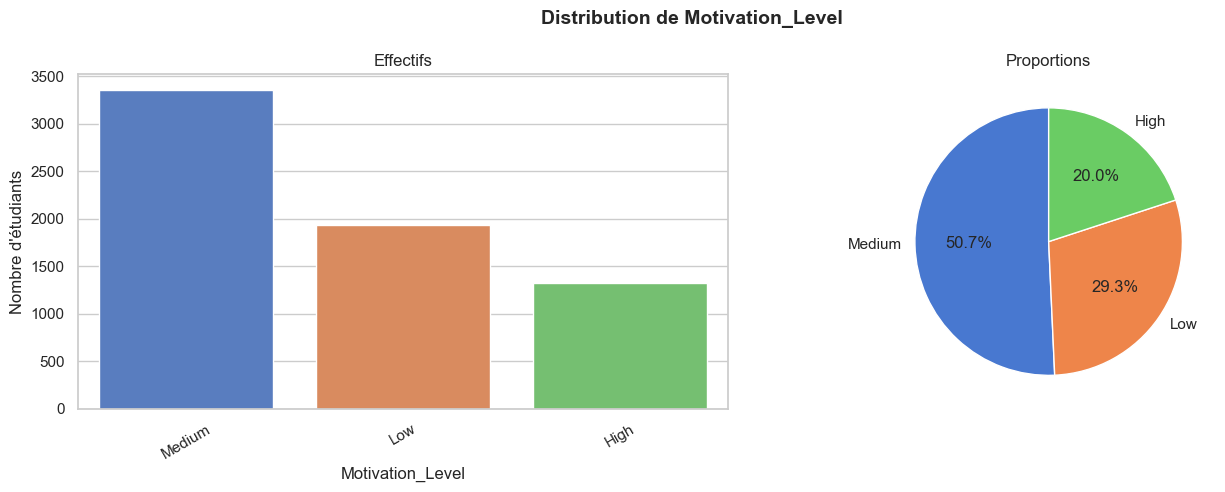

,Modalité,Effectif,Pourcentage
0,Medium,3351,50.72
1,Low,1937,29.32
2,High,1319,19.96



------------------------------------------------------------



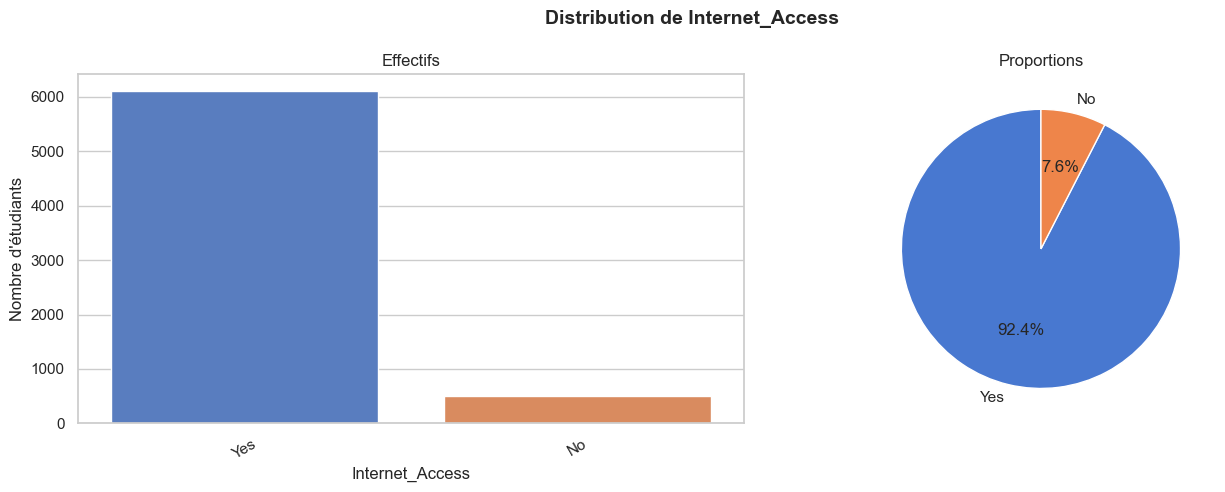

,Modalité,Effectif,Pourcentage
0,Yes,6108,92.45
1,No,499,7.55



------------------------------------------------------------



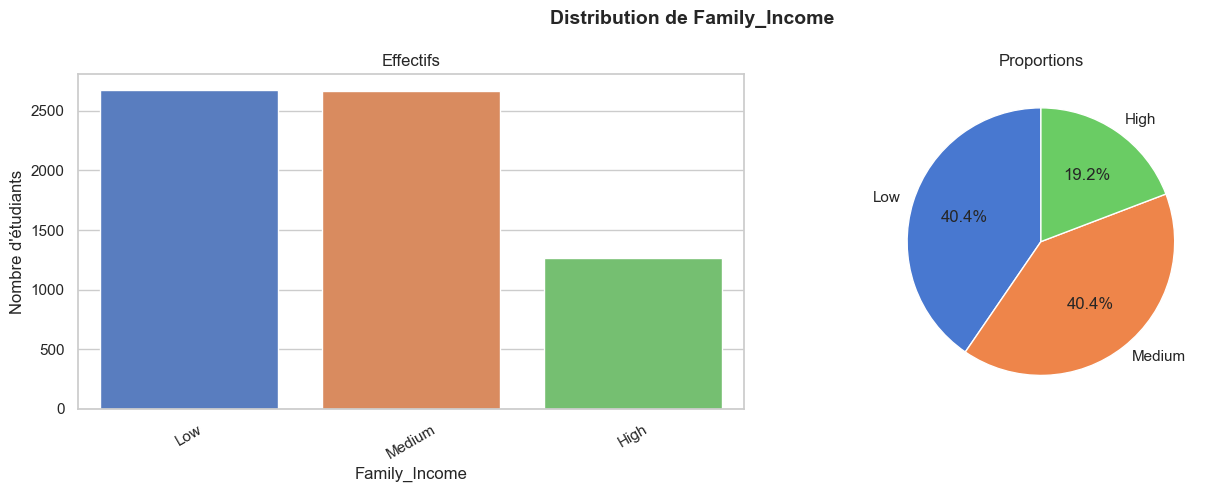

,Modalité,Effectif,Pourcentage
0,Low,2672,40.44
1,Medium,2666,40.35
2,High,1269,19.21



------------------------------------------------------------



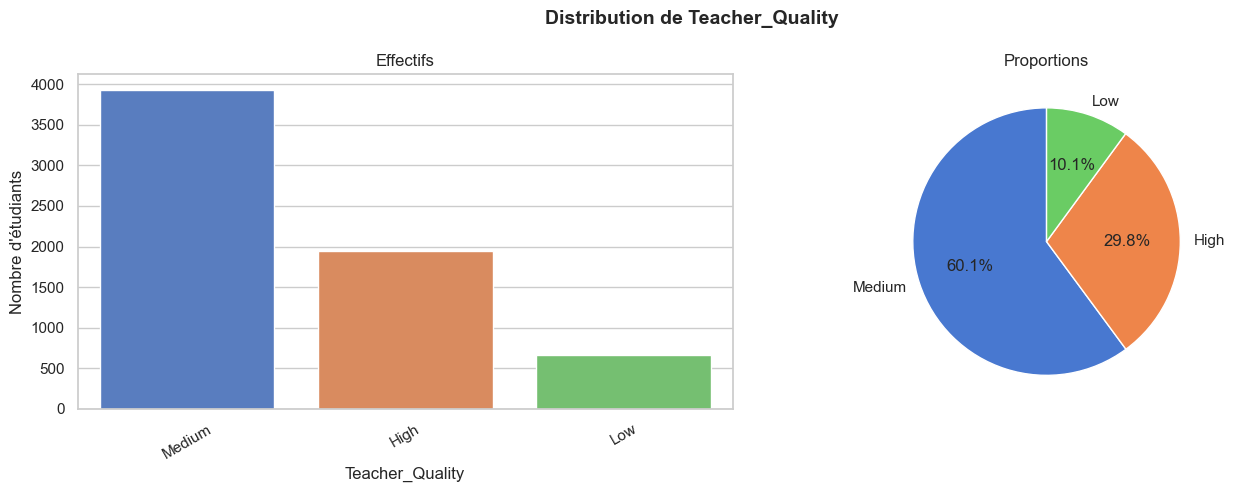

,Modalité,Effectif,Pourcentage
0,Medium,3925,60.12
1,High,1947,29.82
2,Low,657,10.06



------------------------------------------------------------



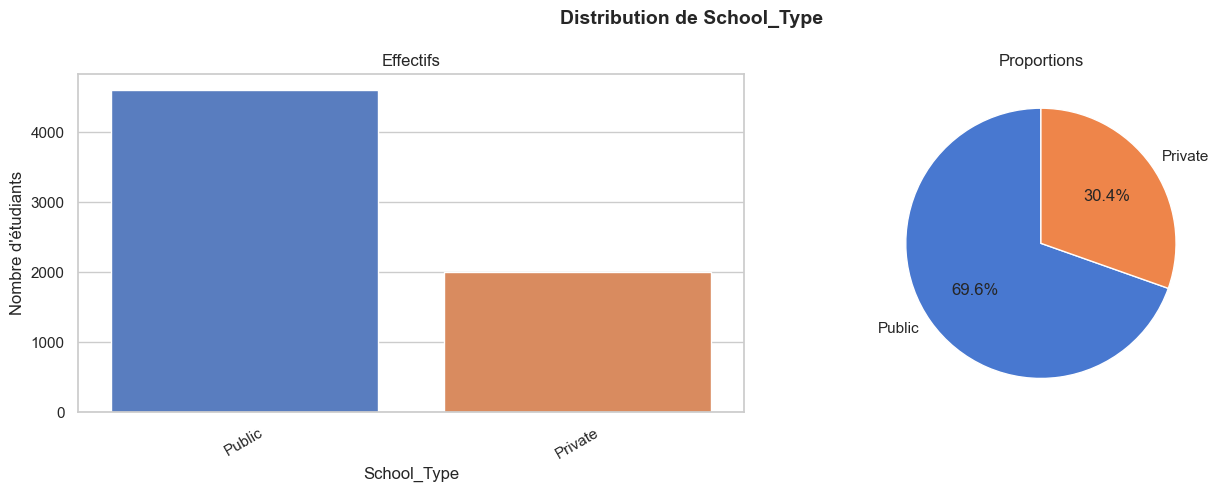

,Modalité,Effectif,Pourcentage
0,Public,4598,69.59
1,Private,2009,30.41



------------------------------------------------------------



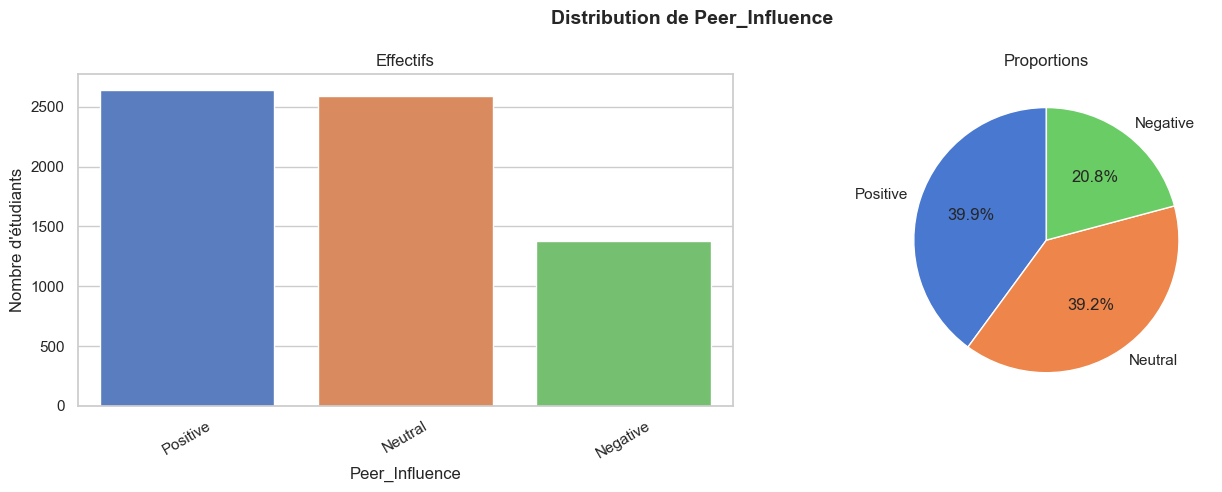

,Modalité,Effectif,Pourcentage
0,Positive,2638,39.93
1,Neutral,2592,39.23
2,Negative,1377,20.84



------------------------------------------------------------



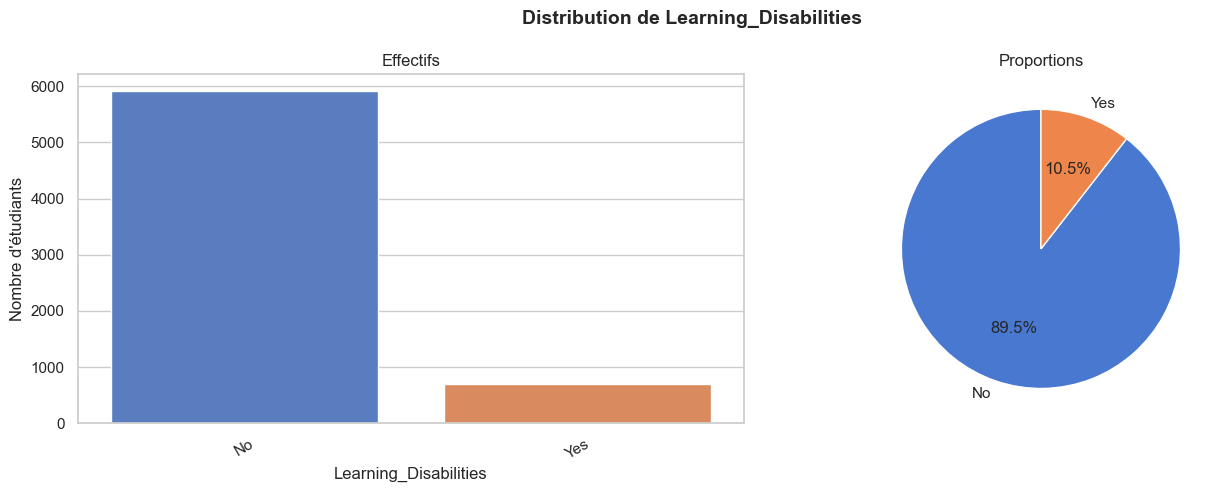

,Modalité,Effectif,Pourcentage
0,No,5912,89.48
1,Yes,695,10.52



------------------------------------------------------------



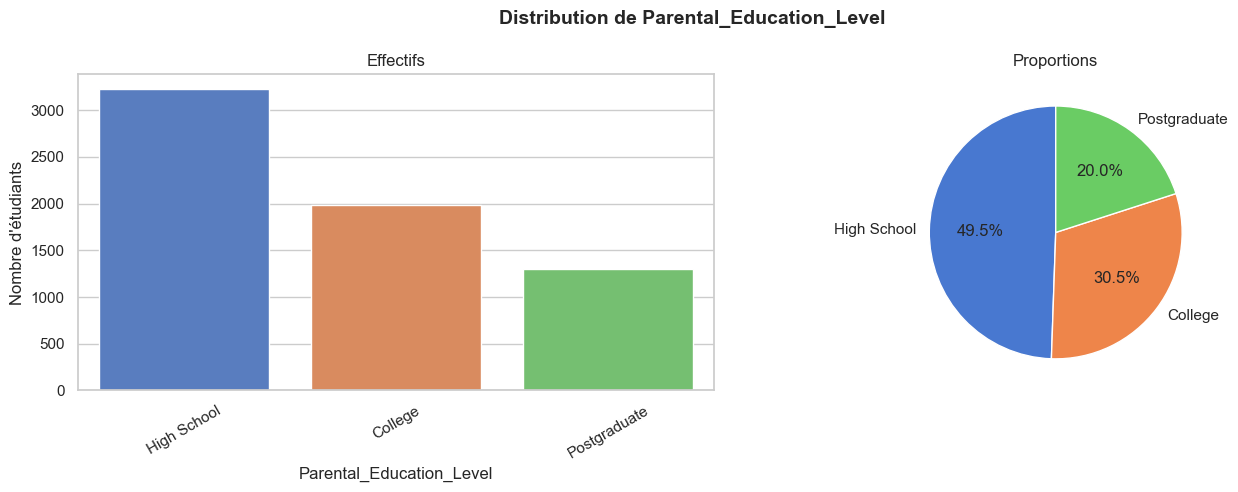

,Modalité,Effectif,Pourcentage
0,High School,3223,49.46
1,College,1989,30.52
2,Postgraduate,1305,20.02



------------------------------------------------------------



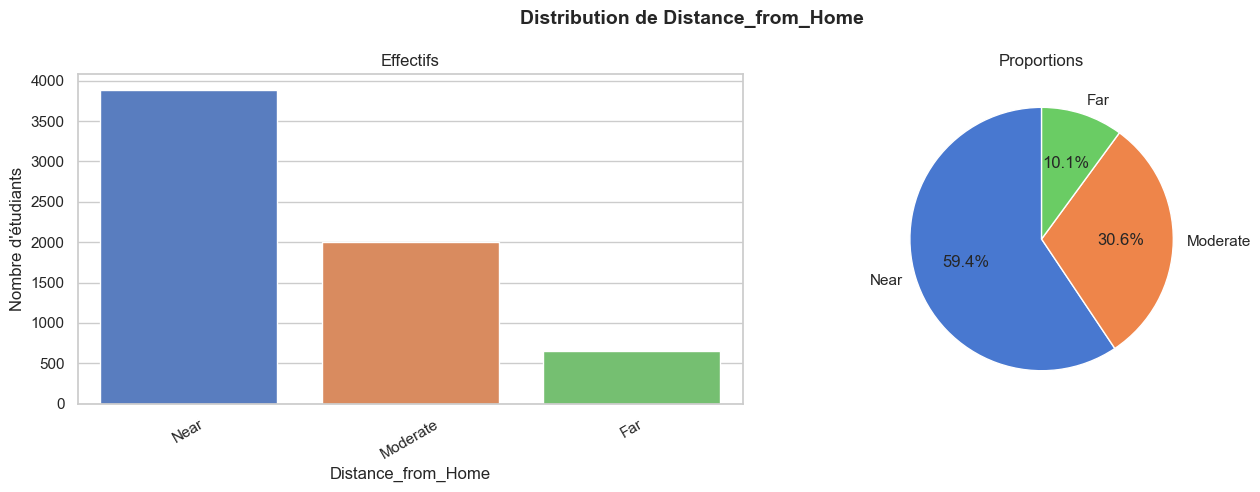

,Modalité,Effectif,Pourcentage
0,Near,3884,59.39
1,Moderate,1998,30.55
2,Far,658,10.06



------------------------------------------------------------



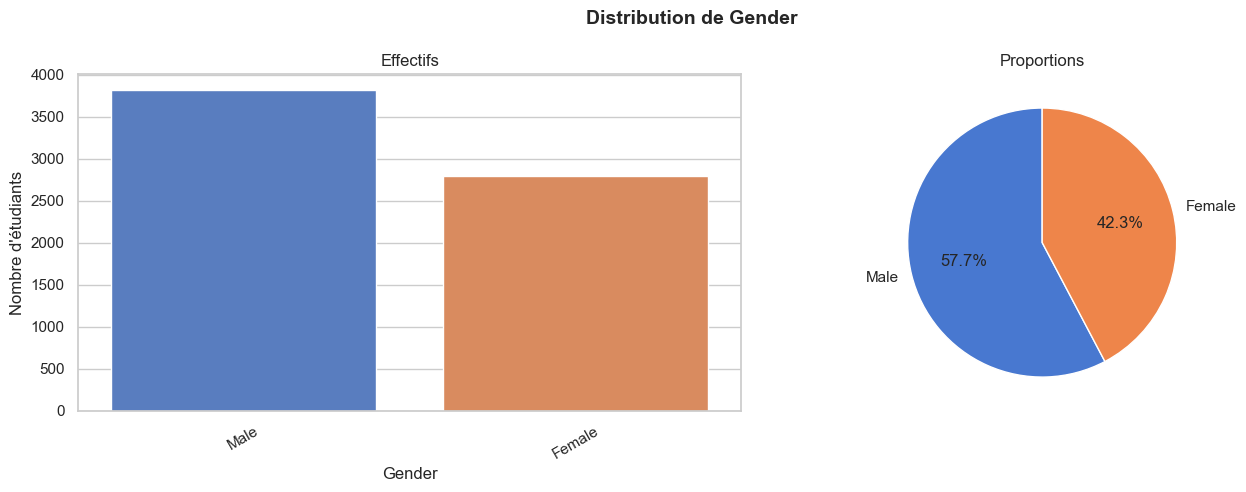

,Modalité,Effectif,Pourcentage
0,Male,3814,57.73
1,Female,2793,42.27



------------------------------------------------------------



In [17]:
# Affichage des distributions pour chaque variable catégorielle
for var in cat_vars:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribution de {var}', fontsize=14, fontweight='bold')
    
    # Diagramme en barres
    order = data[var].value_counts().index
    sns.countplot(x=data[var], order=order, palette='muted', ax=axes[0])
    axes[0].set_title('Effectifs')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Nombre d\'étudiants')
    axes[0].tick_params(axis='x', rotation=30)
    
    # Diagramme en secteurs (proportions)
    data[var].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], 
                                      colors=sns.color_palette('muted'), 
                                      startangle=90)
    axes[1].set_ylabel('')
    axes[1].set_title('Proportions')
    
    plt.tight_layout()
    plt.show()
    
    # Tableau des effectifs et fréquences
    freq_table = pd.DataFrame({
        'Modalité': data[var].value_counts().index,
        'Effectif': data[var].value_counts().values,
        'Pourcentage': (100 * data[var].value_counts(normalize=True).values).round(2)
    })
    display(freq_table)
    print('\n' + '-'*60 + '\n')

### Analyse des variables catégorielles

Les tableaux de fréquences et les graphiques permettent de dégager plusieurs constats.

- **Parental_Involvement** : la modalité "Medium" domine (50,9 %), suivie de "High" (28,9 %) et "Low" (20,2 %).  
  La répartition reste assez équilibrée, aucune catégorie n’est anecdotique.

- **Access_to_Resources** : profil similaire avec "Medium" à 50,2 %, "High" à 29,9 % et "Low" à 19,9 %.  
  L’accès aux ressources est majoritairement moyen ou élevé, la modalité "Low" étant la moins représentée mais sans être marginale.

- **Extracurricular_Activities** : 59,6 % des étudiants participent à des activités extrascolaires ("Yes"), 40,4 % n’y participent pas ("No").  
  L’équilibre est correct, la modalité minoritaire reste bien représentée.

- **Motivation_Level** : "Medium" est majoritaire (50,7 %), "Low" (29,3 %) et "High" (20,0 %) se partagent le reste.  
  La motivation élevée est la moins fréquente, mais l’écart avec "Low" n’est que de 9 points.

- **Internet_Access** : très fort déséquilibre, 92,5 % des étudiants ont accès à Internet ("Yes") contre 7,5 % sans accès ("No").  
  Cette variable risque d’avoir un pouvoir discriminant limité et pourrait même être exclue du modèle si elle n’apporte pas d’information utile.

- **Family_Income** : "Low" (40,4 %) et "Medium" (40,4 %) sont quasiment à égalité, "High" représente 19,2 %.  
  La distribution est acceptable, avec une minorité "High" suffisamment étoffée.

- **Teacher_Quality** : la qualité perçue de l’enseignant est "Medium" pour 60,1 % des étudiants, "High" pour 29,8 % et "Low" pour seulement 10,1 %.  
  La modalité "Low" est faible et les 78 valeurs manquantes (1,18 %) accentuent ce déséquilibre. Une imputation par le mode ("Medium") renforcera encore la majorité.

- **School_Type** : 69,6 % des élèves fréquentent une école publique ("Public"), 30,4 % une école privée ("Private").  
  Le déséquilibre est modéré, les deux modalités restent exploitables.

- **Peer_Influence** : "Positive" (39,9 %) et "Neutral" (39,2 %) sont très proches, "Negative" regroupe 20,8 %.  
  Bon équilibre global.

- **Learning_Disabilities** : 89,5 % des étudiants n’ont pas de troubles de l’apprentissage ("No"), 10,5 % en ont ("Yes").  
  La modalité minoritaire est faible mais avec 695 individus, elle reste suffisante pour être conservée telle quelle.

- **Parental_Education_Level** : "High School" est le niveau le plus fréquent (49,5 %), devant "College" (30,5 %) et "Postgraduate" (20,0 %).  
  La variable comporte 90 valeurs manquantes (1,36 %), l’imputation par le mode ("High School") sera logique.

- **Distance_from_Home** : 59,4 % des élèves habitent près de l’école ("Near"), 30,6 % à distance modérée ("Moderate"), 10,1 % loin ("Far").  
  Avec 67 valeurs manquantes (1,01 %), l’imputation par le mode ("Near") est également indiquée. La modalité "Far" est peu représentée mais acceptable.

- **Gender** : 57,7 % de garçons ("Male"), 42,3 % de filles ("Female").  
  Légère sur-représentation masculine, sans excès.

En synthèse, la plupart des variables catégorielles présentent des distributions utilisables sans regroupement.  
Deux points méritent attention lors du prétraitement :

- **Internet_Access**, très déséquilibrée, pourra être testée avec et sans la variable pour mesurer son impact réel.
- **Teacher_Quality**, **Parental_Education_Level** et **Distance_from_Home** devront être imputées avant encodage.

## 9. Analyse bivariée : relations avec le score d'examen

Cette section explore les liens entre chaque variable explicative et la cible Exam_Score.  
L'objectif est d'identifier les facteurs qui semblent les plus liés au résultat de l'examen.

Dans un premier temps, les variables numériques sont analysées via des nuages de points et des coefficients de corrélation.  
Les variables catégorielles seront traitées ensuite avec des boîtes à moustaches et des tableaux de moyennes.

### 9.1 Variables numériques vs Exam_Score

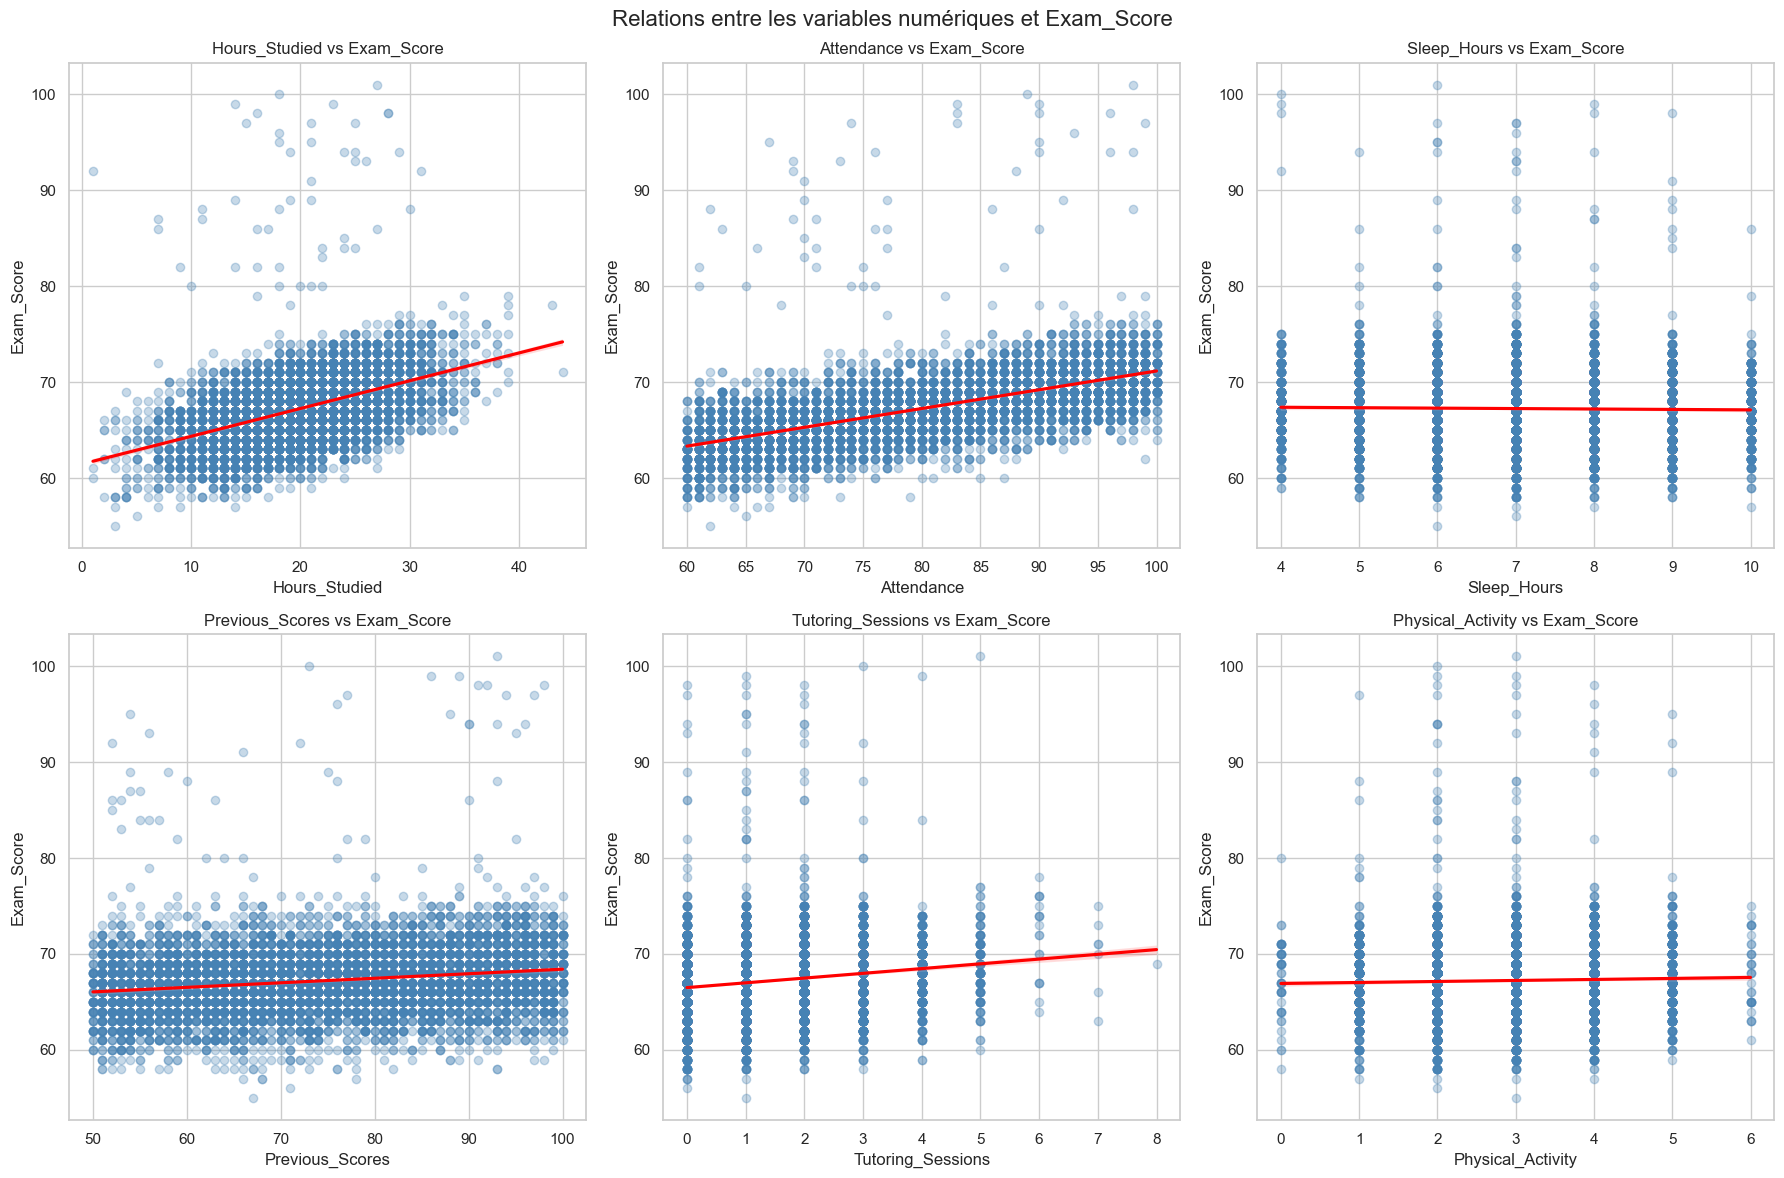

In [18]:
# Nuages de points avec droite de régression pour chaque variable numérique
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Relations entre les variables numériques et Exam_Score', fontsize=16)
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.regplot(x=data[var], y=data['Exam_Score'], 
                scatter_kws={'alpha':0.3, 'color':'steelblue'}, 
                line_kws={'color':'red'}, ax=axes[i])
    axes[i].set_title(f'{var} vs Exam_Score')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Exam_Score')

plt.tight_layout()
plt.show()

In [19]:
# Calcul des corrélations de Pearson et Spearman avec Exam_Score
correlations = {}
for var in num_vars:
    pearson_r = data[var].corr(data['Exam_Score'], method='pearson')
    spearman_rho = data[var].corr(data['Exam_Score'], method='spearman')
    correlations[var] = [pearson_r, spearman_rho]

corr_df = pd.DataFrame(correlations, index=['Pearson (r)', 'Spearman (ρ)']).T
corr_df = corr_df.round(3)
display(corr_df)

,Pearson (r),Spearman (ρ)
Hours_Studied,0.45,0.48
Attendance,0.58,0.67
Sleep_Hours,-0.02,-0.01
Previous_Scores,0.17,0.19
Tutoring_Sessions,0.16,0.16
Physical_Activity,0.03,0.03


### Analyse des relations avec les variables numériques

Le tableau des corrélations et les nuages de points mettent en évidence des liens de force variable avec le score d’examen.

- **Hours_Studied** : corrélation de Pearson de 0,45 et Spearman de 0,48.  
  La relation positive est modérée : plus un étudiant consacre d’heures à l’étude, plus son score a tendance à augmenter. La droite de régression sur le nuage de points est nettement ascendante, avec une dispersion qui reste contenue.

- **Attendance** : corrélation de Pearson de 0,58 et Spearman de 0,67 (la plus élevée parmi les numériques).  
  L’assiduité est le facteur linéaire le plus lié à la performance. La forte corrélation de Spearman indique une relation monotone marquée, même si elle n’est pas parfaitement linéaire. Les absents récurrents ont des scores plus faibles.

- **Sleep_Hours** : corrélation quasi nulle (-0,02).  
  Aucune relation linéaire ni monotone n’est détectée entre la durée de sommeil et le score. Le nuage de points est complètement dispersé horizontalement.

- **Previous_Scores** : corrélation de Pearson de 0,17 et Spearman de 0,19.  
  Étonnamment faible, alors que le describe montrait une distribution comparable à la cible. Ce résultat suggère que le lien entre scores antérieurs et score d’examen n’est pas direct, ou qu’il est masqué par d’autres variables. Une analyse multivariée permettra de mieux comprendre.

- **Tutoring_Sessions** : corrélation de Pearson de 0,16 et Spearman de 0,16.  
  Relation positive mais très faible. Le nombre de séances de tutorat seul n’explique que très peu la variation du score.

- **Physical_Activity** : corrélation proche de zéro (0,03).  
  Comme pour le sommeil, l’activité physique ne montre aucun lien avec la performance à l’examen dans cette analyse univariée.

En résumé, **Attendance** et **Hours_Studied** sont les deux variables numériques les plus corrélées à la cible.  
**Previous_Scores** déçoit avec une corrélation faible, malgré une distribution proche de celle d’Exam_Score.  
**Sleep_Hours** et **Physical_Activity** n’apportent aucune information linéaire exploitable seules.  
Ces constats orienteront la sélection de variables, mais l’analyse des variables catégorielles et les interactions pourraient révéler des effets combinés plus subtils.

### 9.2 Variables catégorielles vs Exam_Score

Pour chaque variable catégorielle, un boxplot compare les distributions de Exam_Score selon les modalités.  
Un tableau des moyennes par catégorie est également affiché, afin de quantifier les écarts observés.

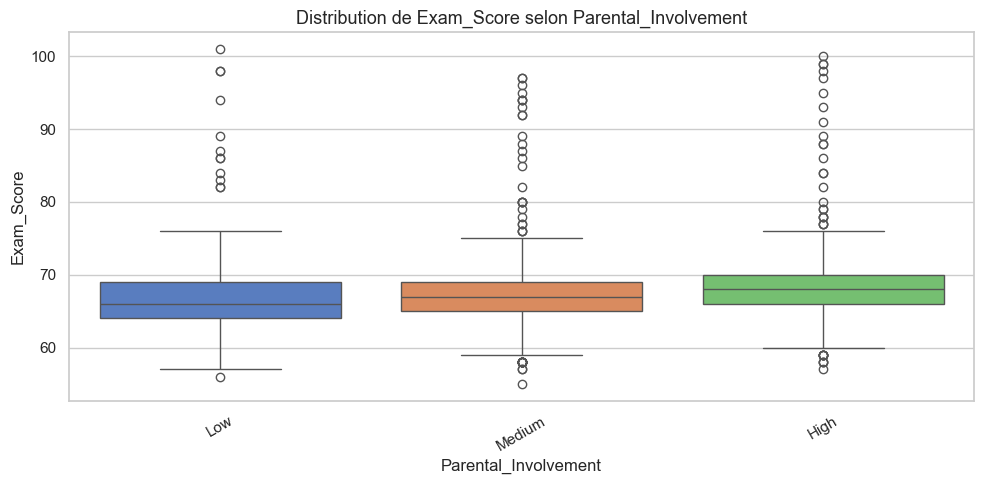

,Effectif,Moyenne,Écart-type
Parental_Involvement,,,
High,1908,68.09,3.95
Medium,3362,67.10,3.73
Low,1337,66.36,3.97



------------------------------------------------------------



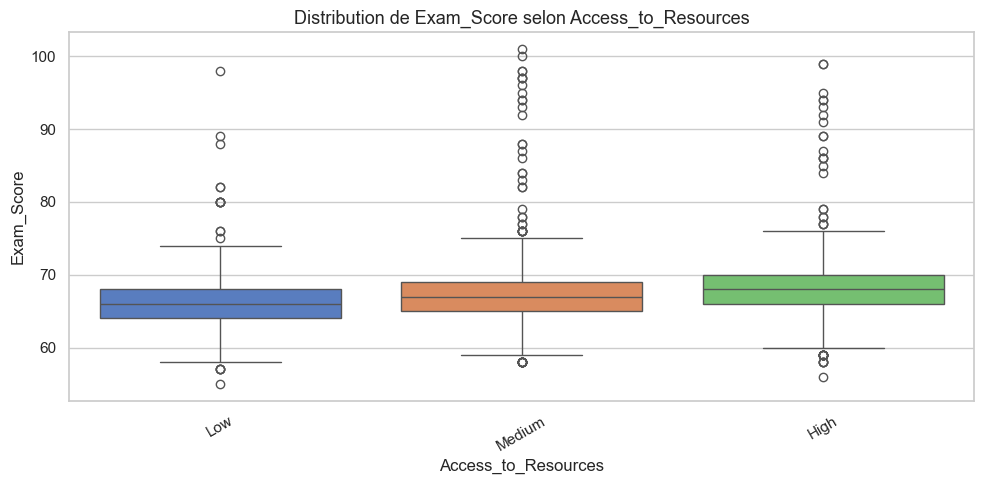

,Effectif,Moyenne,Écart-type
Access_to_Resources,,,
High,1975,68.09,3.95
Medium,3319,67.13,3.87
Low,1313,66.20,3.56



------------------------------------------------------------



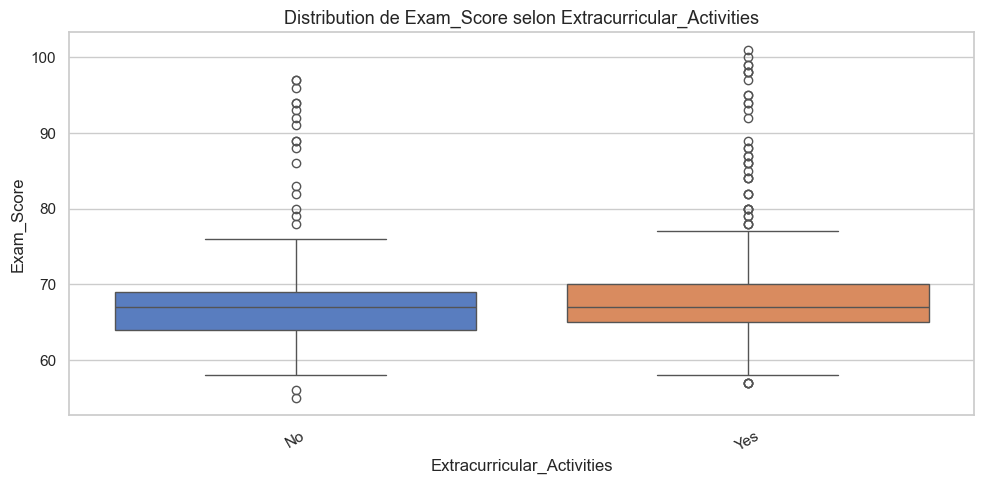

,Effectif,Moyenne,Écart-type
Extracurricular_Activities,,,
Yes,3938,67.44,3.94
No,2669,66.93,3.79



------------------------------------------------------------



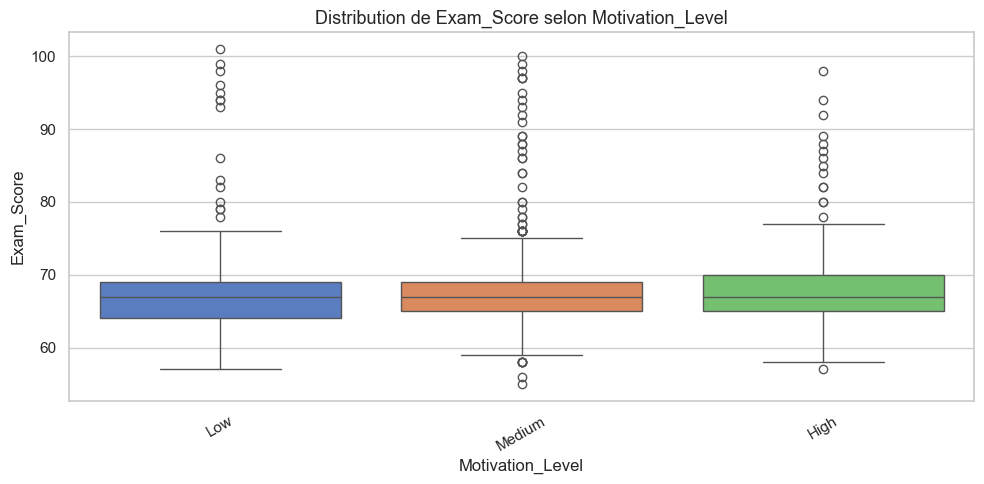

,Effectif,Moyenne,Écart-type
Motivation_Level,,,
High,1319,67.70,3.88
Medium,3351,67.33,3.83
Low,1937,66.75,3.96



------------------------------------------------------------



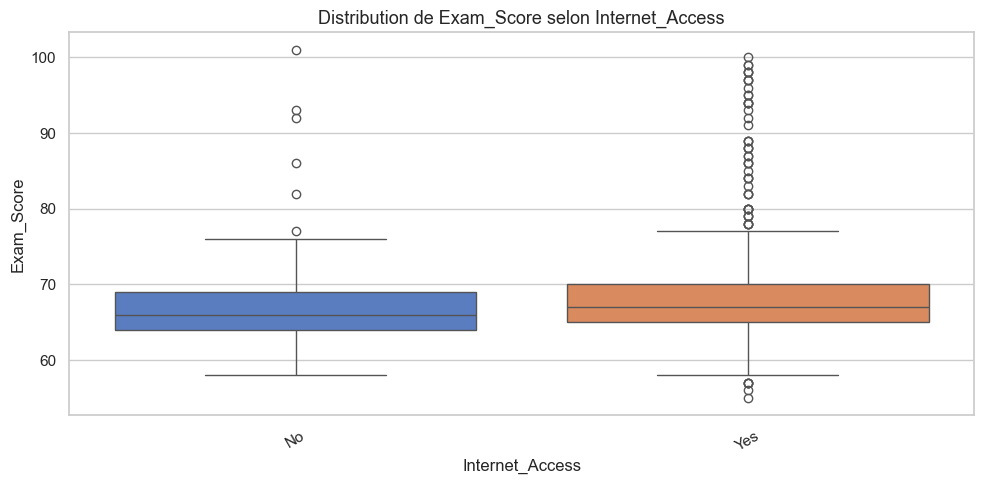

,Effectif,Moyenne,Écart-type
Internet_Access,,,
Yes,6108,67.29,3.87
No,499,66.54,4.12



------------------------------------------------------------



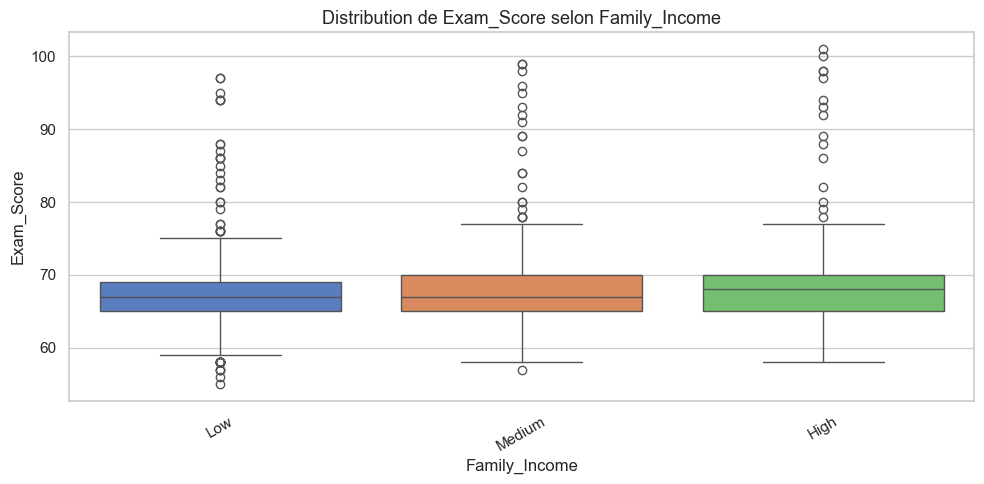

,Effectif,Moyenne,Écart-type
Family_Income,,,
High,1269,67.84,4.16
Medium,2666,67.33,3.81
Low,2672,66.85,3.80



------------------------------------------------------------



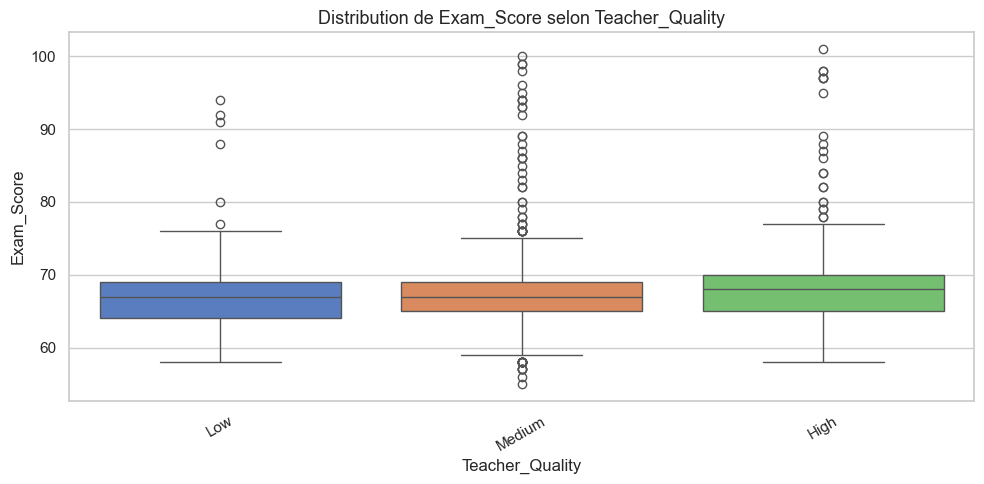

,Effectif,Moyenne,Écart-type
Teacher_Quality,,,
High,1947,67.68,3.98
Medium,3925,67.11,3.85
Low,657,66.75,3.87



------------------------------------------------------------



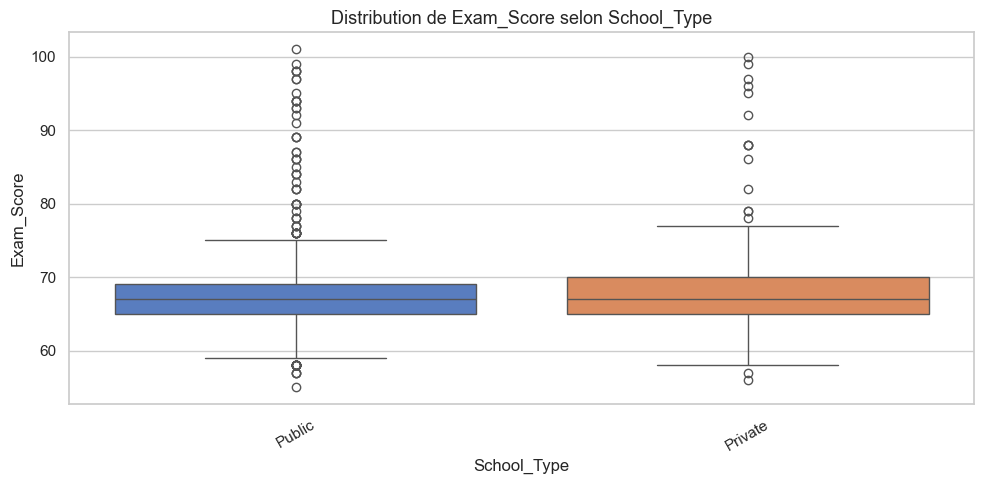

,Effectif,Moyenne,Écart-type
School_Type,,,
Private,2009,67.29,3.85
Public,4598,67.21,3.91



------------------------------------------------------------



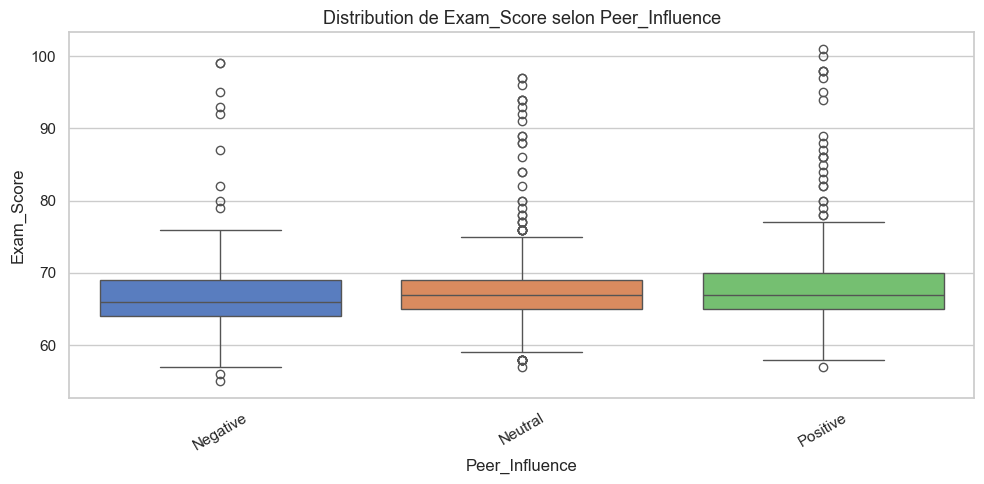

,Effectif,Moyenne,Écart-type
Peer_Influence,,,
Positive,2638,67.62,3.92
Neutral,2592,67.20,3.84
Negative,1377,66.56,3.83



------------------------------------------------------------



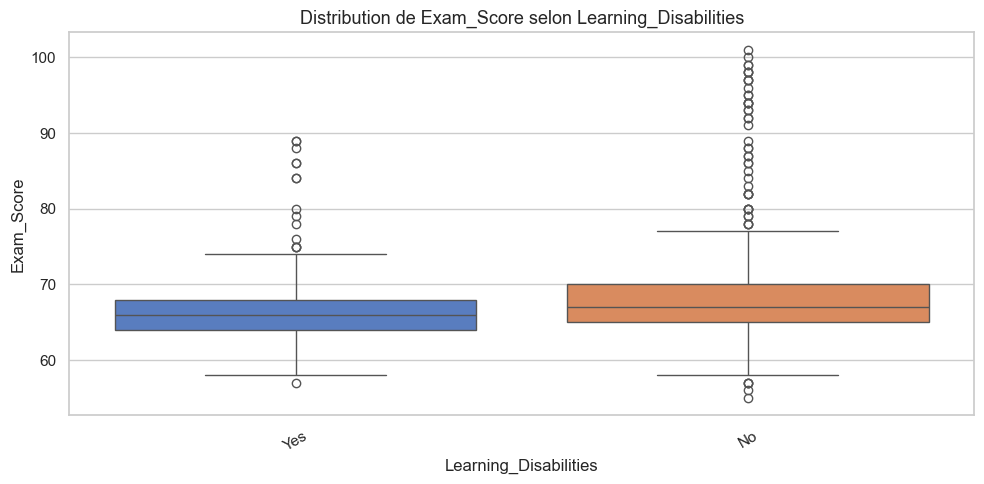

,Effectif,Moyenne,Écart-type
Learning_Disabilities,,,
No,5912,67.35,3.85
Yes,695,66.27,4.07



------------------------------------------------------------



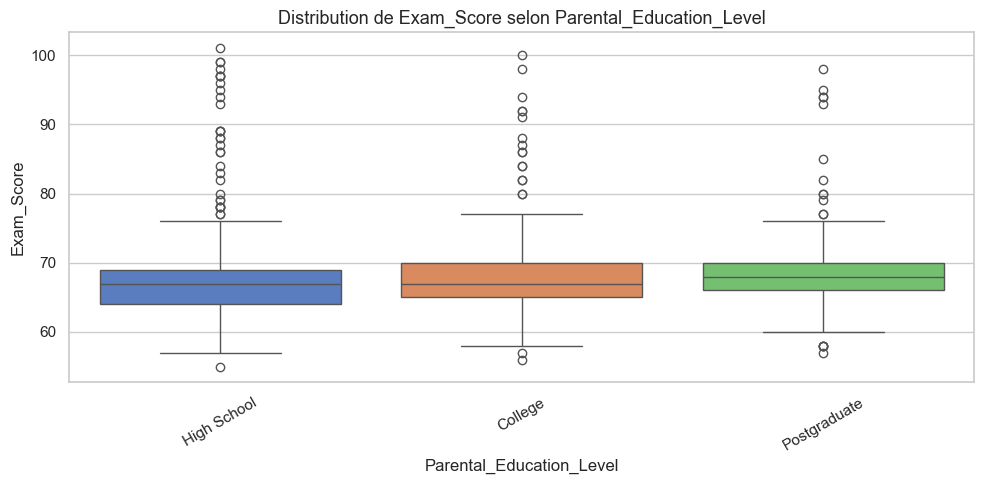

,Effectif,Moyenne,Écart-type
Parental_Education_Level,,,
Postgraduate,1305,67.97,3.69
College,1989,67.32,3.83
High School,3223,66.89,3.98



------------------------------------------------------------



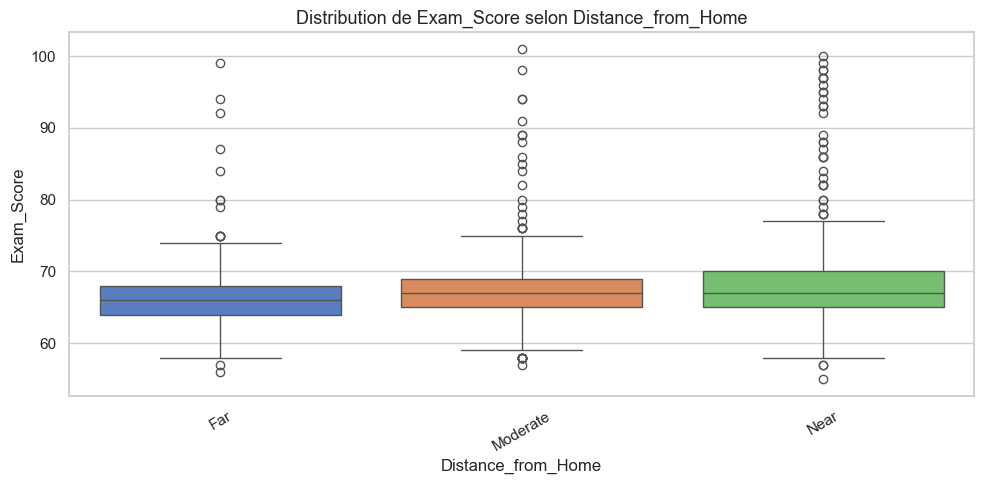

,Effectif,Moyenne,Écart-type
Distance_from_Home,,,
Near,3884,67.51,3.88
Moderate,1998,66.98,3.79
Far,658,66.46,4.14



------------------------------------------------------------



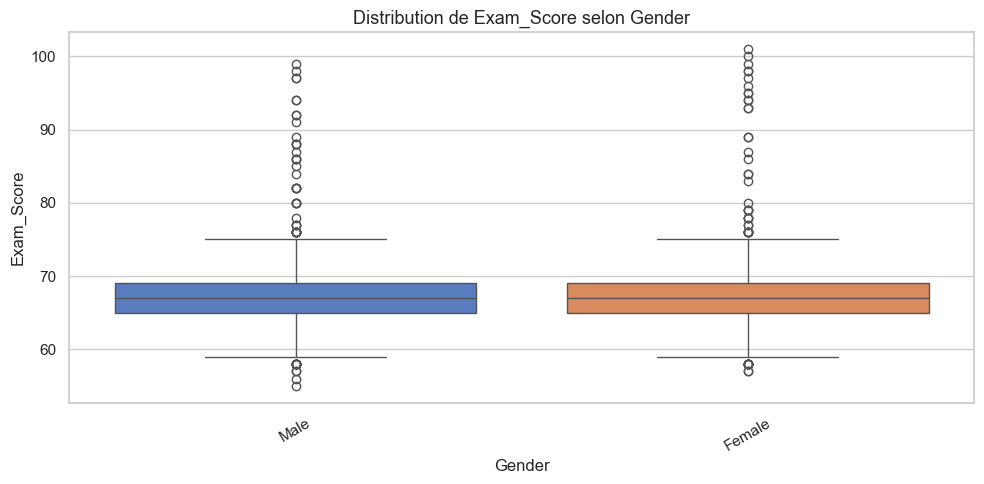

,Effectif,Moyenne,Écart-type
Gender,,,
Female,2793,67.24,4.05
Male,3814,67.23,3.77



------------------------------------------------------------



In [20]:
# Boxplot et tableau des moyennes pour chaque variable catégorielle
for var in cat_vars:
    # Boxplot
    plt.figure(figsize=(10, 5))
    order = data.groupby(var)['Exam_Score'].mean().sort_values().index
    sns.boxplot(x=data[var], y=data['Exam_Score'], order=order, palette='muted')
    plt.title(f'Distribution de Exam_Score selon {var}', fontsize=13)
    plt.xlabel(var)
    plt.ylabel('Exam_Score')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    
    # Tableau des moyennes
    mean_table = data.groupby(var)['Exam_Score'].agg(['count', 'mean', 'std']).round(2)
    mean_table.columns = ['Effectif', 'Moyenne', 'Écart-type']
    mean_table = mean_table.sort_values('Moyenne', ascending=False)
    display(mean_table)
    print('\n' + '-'*60 + '\n')

### Analyse des relations avec les variables catégorielles

Les boîtes à moustaches et les tableaux de moyennes montrent des écarts plus ou moins marqués selon les variables.

- **Parental_Involvement** : la moyenne de Exam_Score augmente avec le niveau d’implication parentale (Low : 66,36, Medium : 67,10, High : 68,09). L’écart entre Low et High est de 1,73 point. L’implication des parents semble avoir un effet positif modeste mais régulier.

- **Access_to_Resources** : même tendance, avec une moyenne qui passe de 66,20 (Low) à 68,09 (High), soit un écart de 1,89 point. L’accès aux ressources éducatives apparaît comme un facteur favorable.

- **Extracurricular_Activities** : les étudiants pratiquant des activités extrascolaires obtiennent en moyenne 67,44 contre 66,93 pour les autres. L’écart est faible (0,51 point). Cette variable semble peu discriminante.

- **Motivation_Level** : la motivation élevée est associée à un score moyen de 67,70, contre 66,75 pour la motivation faible. L’écart de 0,95 point est modeste mais cohérent avec l’idée que la motivation joue un rôle positif.

- **Internet_Access** : les étudiants avec accès à Internet ont une moyenne de 67,29 contre 66,54 pour les autres. L’écart de 0,75 point est faible. Combiné au fort déséquilibre de cette variable (92,5 % de “Yes”), son pouvoir prédictif risque d’être limité.

- **Family_Income** : le revenu familial élevé correspond à la moyenne la plus haute (67,84), devant Medium (67,33) et Low (66,85). L’écart entre Low et High atteint 0,99 point. L’effet est présent mais peu marqué.

- **Teacher_Quality** : la qualité perçue de l’enseignant montre une progression : Low (66,75), Medium (67,11), High (67,68). L’écart de 0,93 point entre Low et High est modeste. Les 78 valeurs manquantes sont exclues de ce calcul.

- **School_Type** : les élèves du privé (67,29) et du public (67,21) ont des moyennes quasi identiques. Le type d’école ne semble pas influencer le score dans cette analyse univariée.

- **Peer_Influence** : l’influence positive des pairs est associée à un score moyen de 67,62, contre 67,20 pour une influence neutre et 66,56 pour une influence négative. L’écart entre Positive et Negative est de 1,06 point, ce qui en fait l’une des variables catégorielles les plus discriminantes avec Parental_Involvement et Access_to_Resources.

- **Learning_Disabilities** : les étudiants sans troubles de l’apprentissage obtiennent en moyenne 67,35, contre 66,27 pour ceux avec des troubles. L’écart de 1,08 point est notable, mais l’effectif de la modalité “Yes” est faible (695 étudiants). Cette variable pourrait capter une difficulté spécifique.

- **Parental_Education_Level** : le score moyen augmente avec le niveau d’éducation des parents : High School (66,89), College (67,32), Postgraduate (67,97). L’écart entre High School et Postgraduate est de 1,08 point. Les 90 valeurs manquantes sont exclues, l’imputation par le mode (“High School”) est à prévoir.

- **Distance_from_Home** : les étudiants habitant près de l’école ont une moyenne de 67,51, contre 66,98 pour une distance modérée et 66,46 pour une distance éloignée. L’écart de 1,05 point suggère que l’éloignement pourrait être un frein. Les 67 valeurs manquantes sont à imputer.

- **Gender** : les moyennes sont quasiment identiques : 67,24 pour les filles, 67,23 pour les garçons. Le genre n’apporte aucune information discriminante.

En synthèse, les variables catégorielles les plus liées au score sont **Parental_Involvement**, **Access_to_Resources**, **Peer_Influence**, **Parental_Education_Level**, **Distance_from_Home** et **Learning_Disabilities**, avec des écarts autour de 1 point.  
**School_Type** et **Gender** semblent sans effet. **Internet_Access** et **Extracurricular_Activities** ont un impact très limité.  
Ces observations devront être confirmées par l’analyse multivariée et la modélisation.

## 10. Matrice de corrélation

La matrice de corrélation permet de visualiser les liens linéaires entre toutes les variables numériques.  
Elle aide à repérer d’éventuelles redondances (multicolinéarité) qui pourraient poser problème à certains modèles, ainsi que les relations entre les variables explicatives elles-mêmes.

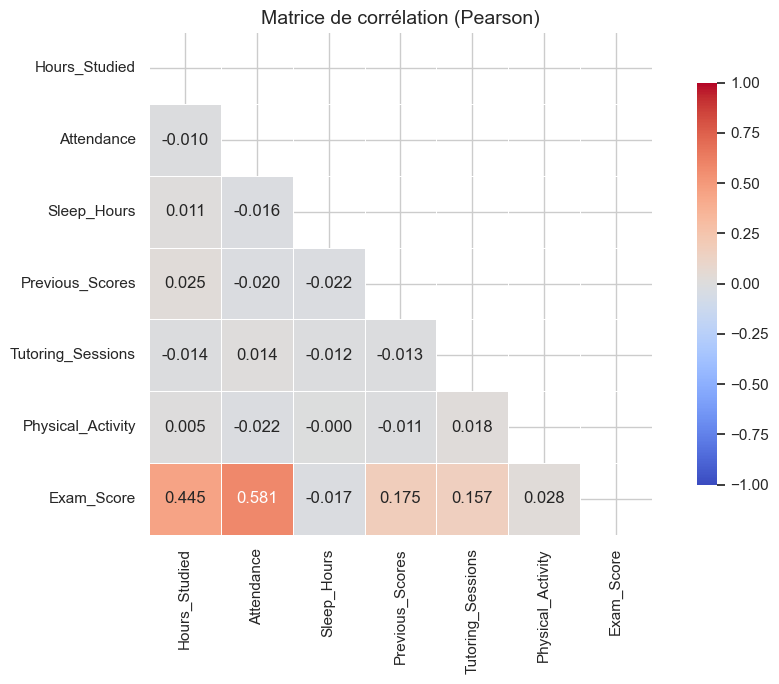

In [21]:
# Calcul de la matrice de corrélation (Pearson)
num_cols_all = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
                'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
corr_matrix = data[num_cols_all].corr(method='pearson')

# Masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Corrélations avec Exam_Score triées par ordre décroissant
corr_with_target = corr_matrix['Exam_Score'].drop('Exam_Score').sort_values(ascending=False)
corr_target_df = pd.DataFrame({
    'Variable': corr_with_target.index,
    'Corrélation avec Exam_Score': corr_with_target.values
}).round(3)
display(corr_target_df)

,Variable,Corrélation avec Exam_Score
0,Attendance,0.58
1,Hours_Studied,0.45
2,Previous_Scores,0.17
3,Tutoring_Sessions,0.16
4,Physical_Activity,0.03
5,Sleep_Hours,-0.02


### Analyse de la matrice de corrélation

Le tableau des corrélations avec Exam_Score confirme et précise les observations de l’analyse bivariée.

- **Attendance** arrive en tête avec une corrélation de 0,58, suivi par **Hours_Studied** à 0,45. Ces deux variables sont les seules à présenter une relation linéaire modérée avec la cible.
- **Previous_Scores** (0,17) et **Tutoring_Sessions** (0,16) affichent des corrélations faibles mais positives.
- **Physical_Activity** (0,03) et **Sleep_Hours** (-0,02) sont quasiment indépendants du score d’examen.

La heatmap complète permet également d’examiner les corrélations entre variables explicatives.  
Aucune paire de variables numériques ne présente de corrélation supérieure à 0,5 en valeur absolue. Les relations entre les prédicteurs sont donc très faibles.

L’absence de multicolinéarité est une bonne nouvelle pour les modèles linéaires : il ne sera pas nécessaire de supprimer ou de combiner des variables pour cause de redondance. Toutefois, les variables catégorielles (non incluses dans cette matrice) pourraient introduire des dépendances une fois encodées.

En conclusion, seules **Attendance** et **Hours_Studied** apportent une information linéaire individuelle notable. Les autres variables numériques devront probablement leur pouvoir prédictif à des interactions ou à des effets non linéaires que les modèles ensemblistes pourront capter.

## 11. Détection des outliers multivariés

Les analyses précédentes ont montré que les variables numériques ne contiennent pas de valeurs aberrantes isolées manifestes.
Cependant, des combinaisons atypiques entre plusieurs variables peuvent exister (par exemple, beaucoup d'heures d'étude associées à un score très faible).
Cette section identifie ces points atypiques à l'aide des résidus de régressions simples avec Exam_Score.

Hours_Studied : 50 outliers détectés sur 6607 points
Attendance : 62 outliers détectés sur 6607 points


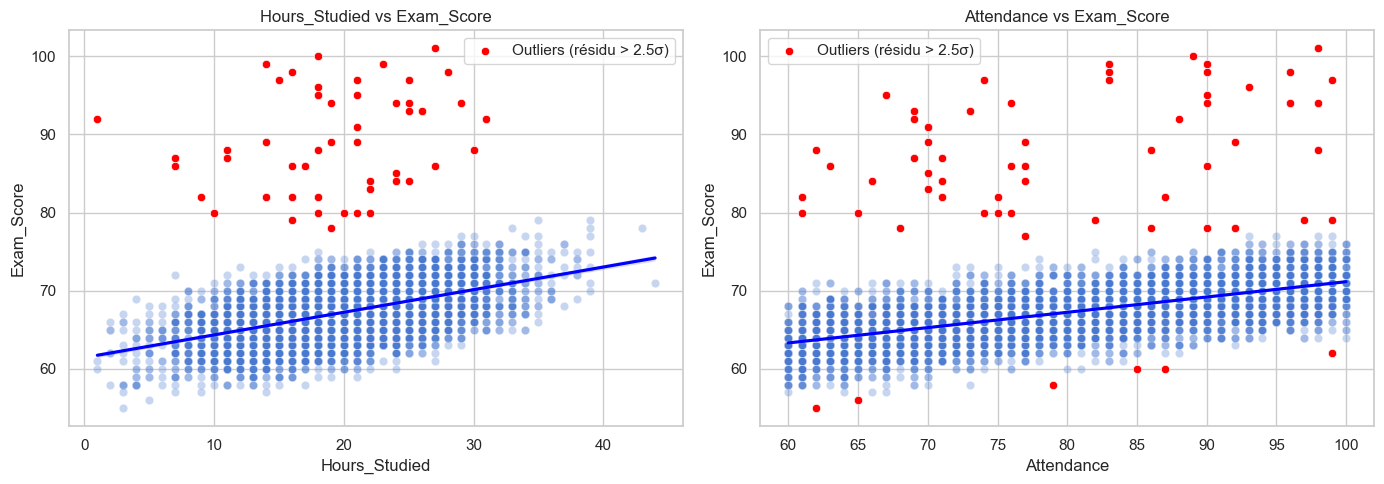

In [23]:
from sklearn.linear_model import LinearRegression

# Fonction pour détecter les outliers basés sur les résidus standardisés
def detect_outliers_residuals(x, y, threshold=2.5):
    """Retourne un masque booléen des points dont le résidu standardisé dépasse threshold."""
    x_reshaped = x.values.reshape(-1, 1)
    model = LinearRegression().fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    residuals = y - y_pred
    std_res = residuals / residuals.std()
    return (np.abs(std_res) > threshold)

# Appliquer pour les deux variables les plus corrélées
outlier_info = {}
for var in ['Hours_Studied', 'Attendance']:
    mask = detect_outliers_residuals(data[var], data['Exam_Score'], threshold=2.5)
    outlier_info[var] = mask.sum()
    print(f"{var} : {mask.sum()} outliers détectés sur {len(data)} points")

# Nuages de points avec outliers mis en évidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, var in zip(axes, ['Hours_Studied', 'Attendance']):
    mask = outlier_info[var]  # on recalcule, mais on peut stocker le mask
    # Recalcul pour le graphique
    mask = detect_outliers_residuals(data[var], data['Exam_Score'], threshold=2.5)
    sns.scatterplot(x=data[var], y=data['Exam_Score'], alpha=0.3, legend=False, ax=ax)
    sns.scatterplot(x=data.loc[mask, var], y=data.loc[mask, 'Exam_Score'], 
                    color='red', label='Outliers (résidu > 2.5σ)', ax=ax)
    # droite de régression
    sns.regplot(x=data[var], y=data['Exam_Score'], scatter=False, 
                line_kws={'color':'blue'}, ax=ax)
    ax.set_title(f'{var} vs Exam_Score')
    ax.legend()
plt.tight_layout()
plt.show()

### Analyse des outliers multivariés

La détection par résidus standardisés (seuil à 2,5 écarts-types) identifie un petit nombre de combinaisons atypiques entre les deux principales variables numériques et le score d’examen.

- **Hours_Studied** : 50 points (0,76 % des étudiants) s’écartent de la tendance générale. Il s’agit d’élèves dont le score est nettement supérieur ou inférieur à ce que laisserait attendre leur nombre d’heures d’étude.
- **Attendance** : 62 points (0,94 %) présentent un écart notable par rapport à la droite de régression.

Ces faibles proportions confirment que les données sont globalement cohérentes. Les points détectés ne sont pas des erreurs manifestes mais des profils atypiques qu’il est intéressant de conserver : un élève très assidu avec un score bas peut signaler une difficulté particulière, tout comme un élève peu studieux avec un score élevé.

Aucune suppression n’est envisagée à ce stade. Les modèles ensemblistes (forêts aléatoires, gradient boosting) sont naturellement robustes à ce type d’atypies, et les modèles linéaires pourront être testés avec et sans ces points pour mesurer leur influence.

## 12. Synthèse et premières décisions pour la modélisation

L’exploration du jeu de données a permis de dégager plusieurs constats qui guideront la phase de prétraitement et de modélisation.

### Données et valeurs manquantes

- Le dataset contient **6607 lignes** et **20 colonnes** (13 catégorielles, 7 numériques).
- La cible **Exam_Score** est complète (aucune valeur manquante) et varie de 55 à 101.
- Seules trois colonnes présentent des valeurs manquantes, avec des taux très faibles (moins de 1,4 %) :  
  Teacher_Quality (78), Parental_Education_Level (90), Distance_from_Home (67).  
  Une imputation par le mode sera appliquée à ces trois variables.

### Variable cible

- La distribution de Exam_Score est asymétrique à droite (skewness 1,64) et très concentrée (kurtosis 10,58).  
  Aucune transformation n’est indispensable, mais il faudra surveiller les résidus et tester des modèles robustes aux valeurs extrêmes.
- Un seul étudiant dépasse 100 (score de 101). Cette valeur pourra être ramenée à 100 lors du nettoyage.

### Variables numériques explicatives

- **Attendance** et **Hours_Studied** sont les deux variables les plus corrélées linéairement avec la cible (r = 0,58 et 0,45).  
- Les autres variables numériques (Sleep_Hours, Previous_Scores, Tutoring_Sessions, Physical_Activity) montrent des corrélations faibles ou nulles.
- Aucune multicolinéarité n’a été détectée entre les variables numériques (toutes les corrélations inter-prédicteurs sont inférieures à 0,5).
- Les échelles sont très différentes, une **standardisation** sera appliquée pour les modèles sensibles à l’échelle (régression ridge, KNN).
- La variable Tutoring_Sessions, asymétrique, pourra faire l’objet d’une discrétisation ou d’une transformation si nécessaire.

### Variables catégorielles explicatives

- **Internet_Access** est très déséquilibrée (92,5 % de “Yes”) ; son utilité devra être vérifiée par les modèles.
- **Learning_Disabilities** est également déséquilibrée mais identifie un sous-groupe d’étudiants potentiellement à risque.
- Les autres variables catégorielles ont des répartitions acceptables.
- Les variables les plus discriminantes vis-à-vis de la cible sont **Parental_Involvement**, **Access_to_Resources**, **Peer_Influence**, **Parental_Education_Level**, **Distance_from_Home** et **Learning_Disabilities**, avec des écarts de moyenne autour de 1 point.
- **School_Type** et **Gender** ne montrent quasiment aucun écart.
- L’encodage retenu sera le **One-Hot Encoding** pour les variables nominales, et un encodage ordinal pour les variables présentant une hiérarchie naturelle (Motivation_Level, Parental_Involvement, etc.).

### Outliers

- Les variables numériques prises isolément ne présentent pas de valeur aberrante flagrante.
- L’analyse des résidus multivariés a révélé moins de 1 % de combinaisons atypiques. Ces points seront conservés.

### Stratégie de modélisation

1. Séparer les données en un jeu d’entraînement (70 %) et un jeu de test (30 %).
2. Construire un pipeline de prétraitement incluant :
   - Imputation des valeurs manquantes par le mode (variables catégorielles).
   - Plafonnement de Exam_Score à 100 si la valeur 101 est confirmée comme une anomalie.
   - Standardisation des variables numériques.
   - Encodage des variables catégorielles (One-Hot avec regroupement éventuel des modalités rares).
3. Tester plusieurs modèles de régression :
   - Régression linéaire simple (baseline).
   - Régression ridge et lasso.
   - KNN.
   - Arbre de décision.
   - Forêt aléatoire.
   - Gradient boosting (XGBoost, LightGBM).
4. Optimiser les hyperparamètres par validation croisée (GridSearchCV).
5. Évaluer les performances avec plusieurs métriques : MAE, RMSE, MAPE, R².
6. Sélectionner le modèle offrant le meilleur compromis entre performance, robustesse et interprétabilité.

Le notebook suivant mettra en œuvre ces étapes et comparera les modèles.